## analysing enso characteristics and its changes cdrmip experiments

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import numpy as np
import os
import xarray as xr
import xcdat as xc
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm as BM
import pandas as pd
import matplotlib as mpl
import matplotlib.ticker as mticker
import netCDF4
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.util import add_cyclic_point
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

In [3]:
import cmocean

In [4]:
from scipy import stats

In [ ]:
mpl.rcParams['font.family'] = 'Droid Sans'
mpl.rcParams['font.size'] = 14
# Edit axes parameters
mpl.rcParams['axes.linewidth'] = 0.8
# Tick properties
mpl.rcParams['xtick.major.size'] = 5
mpl.rcParams['xtick.minor.size'] = 3
mpl.rcParams['xtick.major.width'] = 1
mpl.rcParams['xtick.direction'] = 'out'
mpl.rcParams['ytick.major.size'] = 5
mpl.rcParams['ytick.minor.size'] = 3
mpl.rcParams['ytick.major.width'] = 1
mpl.rcParams['ytick.direction'] = 'out'

In [ ]:
def plot_decorator():
    ax = plt.gca()
    
    # Minor ticks
    # ax.minorticks_on()
    # plt.tick_params(which='minor', axis='x', bottom=False)
    
    # Grid (light, behind data)
    ax.grid(color='gray', lw=0.4, alpha=0.1)
    
    # Remove top/right spines (Nature style)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Tight layout
    # plt.tight_layout()

In [7]:
import matplotlib as mpl
from matplotlib.colors import BoundaryNorm as BM
from matplotlib.colors import TwoSlopeNorm as TSN
from matplotlib.colors import LogNorm as LM
import matplotlib.patches as mpatches

In [8]:
def plot_background(ax):
    ax.add_feature(cfeature.COASTLINE, alpha=0.9, lw=1.1)
    # ax.set_global()
    # ax.add_feature(cfeature.LAND, color='lightgray')
    # ax.add_feature(cfeature.OCEAN, color='lightgray')
    gl = ax.gridlines(draw_labels=True,
                      linewidth=1, color='gray', alpha=0.01, linestyle='--')
    gl.top_labels = False
    # gl.left_labels = False
    # gl.bottom_labels = False
    gl.right_labels = False
    gl.xlines = False
    # gl.xlocator = mticker.FixedLocator([-180, -45, 0, 45, 180])
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlabel_style = {'size': 10, 'color': 'k'}
    gl.ylabel_style = {'size': 10, 'color': 'k'}
    return ax


def plot_maps(x, y, z, titles, labels, cmap, levels, cbar_label = 'Precip', pval = [], draw_winds=False, u_wnd=[], v_wnd=[], wind_scale=20, draw_contour=False, contour_data=[], contour_levels=[], contour_colors='gray', nrows=1, ncols=3, figsize=(12,4), land_mask_list = [0], add_patch=False, add_patch_extra=False, cbar_orientation='vertical', hatch_type = 'insig', proj=ccrs.Robinson(central_longitude=160)):
    fig, axarr = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize, constrained_layout=True, subplot_kw={'projection':proj})
    
    axlist = axarr.flatten()
    
    for ax in axlist:
        plot_background(ax)
    
    for i in range(len(z)):
        axlist[i].contourf(x, y, z[i], cmap = cmap, transform = ccrs.PlateCarree(central_longitude=0), levels=levels, extend='both')
        axlist[i].set_title(titles[i])
        if draw_winds:
            axlist[i].quiver(x[::3, ::3], y[::3, ::3], u_wnd[i].to_numpy()[::3, ::3], v_wnd[i].to_numpy()[::3, ::3], scale=wind_scale, color='k', transform=ccrs.PlateCarree())
        if draw_contour:
            axlist[i].contour(x, y, contour_data[i], cmap = None, levels=contour_levels, colors=contour_colors, transform = ccrs.PlateCarree(central_longitude=0))
        if i in land_mask_list:
            axlist[i].add_feature(cfeature.LAND, color = 'k', zorder=1)
        if pval != []:
            if hatch_type == 'insig':
                pval_plot = np.ma.masked_less_equal(pval[i], 0.05)
            elif hatch_type == 'sig':
                pval_plot = np.ma.masked_greater(pval[i], 0.05)
            axlist[i].pcolor(x, y, pval_plot, alpha = 0., hatch='////', transform = ccrs.PlateCarree(central_longitude=0))
        axlist[i].set_title(titles[i], fontdict={'fontsize':12})
        axlist[i].text(0.1, 1.05, labels[i], size=16, fontweight='bold', transform=axlist[i].transAxes)
        if add_patch:
            # axlist[i].add_patch(mpatches.Rectangle(xy=[120, -65], width=170, height=20,
            #                                 facecolor='none', edgecolor='k',
            #                                 transform=ccrs.PlateCarree()))
            axlist[i].add_patch(mpatches.Rectangle(xy=[190, -5], width=80, height=10,
                                            facecolor='none', edgecolor='k',
                                            transform=ccrs.PlateCarree()))
            axlist[i].add_patch(mpatches.Rectangle(xy=[140, -5], width=30, height=10,
                                            facecolor='none', edgecolor='k',
                                            transform=ccrs.PlateCarree()))
            # axlist[i].add_patch(mpatches.Rectangle(xy=[250, -30], width=40, height=20,
            #                                 facecolor='none', edgecolor='k',
            #                                 transform=ccrs.PlateCarree()))
            # axlist[i].add_patch(mpatches.Rectangle(xy=[140, 60], width=150, height=20,
            #                                             facecolor='none', edgecolor='tab:green', lw=1.5,
            #                                             transform=ccrs.PlateCarree()))
            # axlist[i].add_patch(mpatches.Rectangle(xy=[140, -80], width=150, height=20,
            #                                             facecolor='none', edgecolor='tab:green', lw=1.5,
            #                                             transform=ccrs.PlateCarree()))
        if add_patch_extra:
            axlist[i].add_patch(mpatches.Rectangle(xy=[190, 20], width=60, height=20,
                                                        facecolor='none', edgecolor='k', lw=1.5,
                                                        transform=ccrs.PlateCarree()))
            axlist[i].add_patch(mpatches.Rectangle(xy=[210, -40], width=60, height=30,
                                                        facecolor='none', edgecolor='k', lw=1.5,
                                                        transform=ccrs.PlateCarree()))
                    
    norm = BM(levels, 256, extend='both')
    fig.colorbar(mpl.cm.ScalarMappable(norm = norm, cmap=cmap), ax = axlist, \
                orientation = cbar_orientation, shrink=0.8, aspect = 45, pad = 0.05, label = cbar_label)

In [9]:
from functions import preproc_funcs as funcs

### importing data

In [ ]:
models_cdr = [
    'ACCESS-ESM1-5',
    # 'CAS-ESM2-0', # tas not available
    'CanESM5',
    'CESM2',
    'CNRM-ESM2-1',
    'MIROC-ES2L',
    'GFDL-ESM4',
    'NorESM2-LM',
    'UKESM1-0-LL',
]

In [11]:
list_pic = []

for m in range(len(models_cdr)):
    ds = xr.open_dataset(f'/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/zecmip/{models_cdr[m]}_pic_tas.nc', use_cftime=True).tas
    list_pic.append(funcs.calc_anom(ds, ds.isel(time = slice(0, 350))))

pic_dat = dict(zip(list(models_cdr), list_pic))

In [12]:
list_1pctco2 = []
list_cdr = []
for m in range(len(models_cdr)):
    base = xr.open_dataset(f'/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/zecmip/{models_cdr[m]}_pic_tas.nc', use_cftime=True).tas
    ds = xr.open_dataset(f'/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/zecmip/{models_cdr[m]}_1pctco2_tas.nc', use_cftime=True).tas.load()
    if models_cdr[m] == 'GISS-E2-1-G-CC':
        list_1pctco2.append(funcs.calc_anom(ds.isel(model=2).drop('model'), base.isel(time = slice(0, 350))))
    else:
        list_1pctco2.append(funcs.calc_anom(ds, base.isel(time = slice(0, 350))))
    ds1 = xr.open_dataset(f'/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/cdrmip/{models_cdr[m]}_cdr_tas.nc', use_cftime=True).tas.load()
    list_cdr.append(funcs.calc_anom(ds1, base.isel(time = slice(0, 350))))

trans_dat = dict(zip(list(models_cdr), list_1pctco2))
cdr_dat = dict(zip(list(models_cdr), list_cdr))

In [13]:
weights = np.cos(np.deg2rad(trans_dat[models_cdr[0]].lat))
weights

<xarray.DataArray 'lat' (lat: 120)>
array([0.0130896 , 0.03925982, 0.06540313, 0.09150162, 0.1175374 ,
       0.14349262, 0.1693495 , 0.19509032, 0.22069744, 0.24615329,
       0.27144045, 0.29654157, 0.32143947, 0.34611706, 0.37055744,
       0.39474386, 0.41865974, 0.44228869, 0.46561452, 0.48862124,
       0.51129309, 0.53361452, 0.55557023, 0.57714519, 0.5983246 ,
       0.61909395, 0.639439  , 0.65934582, 0.67880075, 0.69779046,
       0.71630194, 0.73432251, 0.75183981, 0.76884183, 0.78531693,
       0.80125381, 0.81664156, 0.83146961, 0.84572782, 0.85940641,
       0.87249601, 0.88498764, 0.89687274, 0.90814317, 0.91879121,
       0.92880955, 0.93819134, 0.94693013, 0.95501994, 0.96245524,
       0.96923091, 0.97534232, 0.98078528, 0.98555606, 0.98965139,
       0.99306846, 0.99580493, 0.99785892, 0.99922904, 0.99991433,
       0.99991433, 0.99922904, 0.99785892, 0.99580493, 0.99306846,
       0.98965139, 0.98555606, 0.98078528, 0.97534232, 0.96923091,
       0.96245524, 0.95501994, 0.94693013, 0.93819134, 0.92880955,
       0.91879121, 0.90814317, 0.89687274, 0.88498764, 0.87249601,
       0.85940641, 0.84572782, 0.83146961, 0.81664156, 0.80125381,
       0.78531693, 0.76884183, 0.75183981, 0.73432251, 0.71630194,
       0.69779046, 0.67880075, 0.65934582, 0.639439  , 0.61909395,
       0.5983246 , 0.57714519, 0.55557023, 0.53361452, 0.51129309,
       0.48862124, 0.46561452, 0.44228869, 0.41865974, 0.39474386,
       0.37055744, 0.34611706, 0.32143947, 0.29654157, 0.27144045,
       0.24615329, 0.22069744, 0.19509032, 0.1693495 , 0.14349262,
       0.1175374 , 0.09150162, 0.06540313, 0.03925982, 0.0130896 ])
Coordinates:
  * lat      (lat) float64 -89.25 -87.75 -86.25 -84.75 ... 86.25 87.75 89.25
Attributes:
    bounds:         lat_bounds
    standard_name:  latitude
    units:          degrees_north

In [14]:

import seaborn as sns

### enso

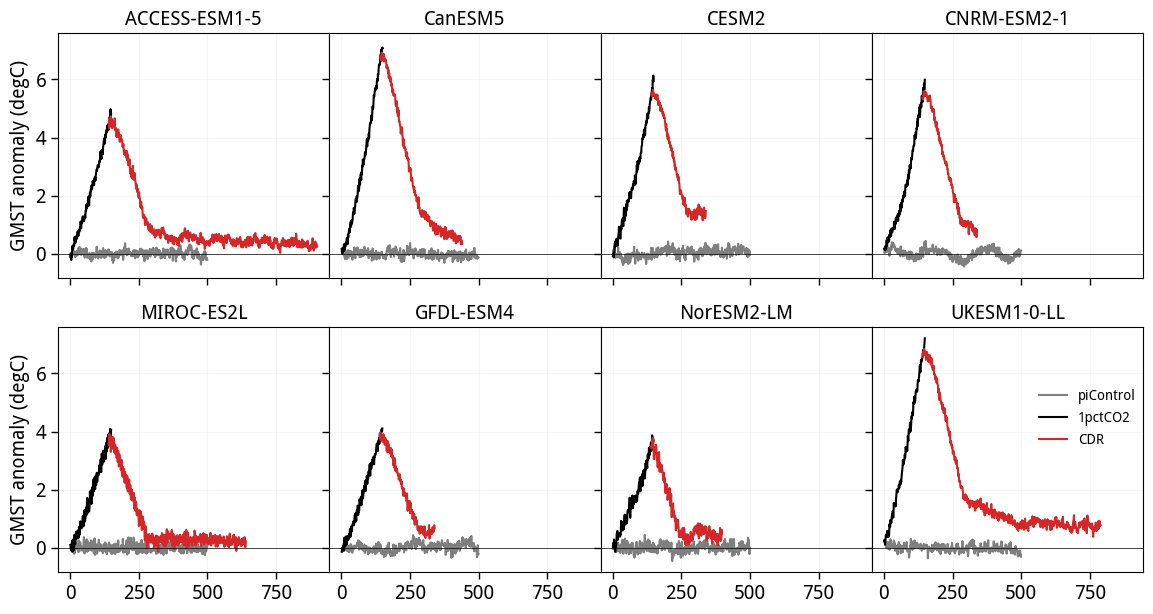

In [ ]:
fig, axarr = plt.subplots(nrows=2, ncols=4, figsize=(14,7), constrained_layout=True, sharex=True, sharey=True)
axlist = axarr.flatten()
for i in range(len(axlist)):
    xdata0 = pic_dat[models_cdr[i]].time.dt.year
    axlist[i].plot((xdata0 - xdata0[0])[1:500], pic_dat[models_cdr[i]].weighted(weights).mean(('lat', 'lon')).isel(time = slice(1, 500), model=0), color='tab:gray', label='piControl')
    xdata = pic_dat[models_cdr[i]].time.dt.year
    #
    xdata0 = trans_dat[models_cdr[i]].time.dt.year
    axlist[i].plot((xdata0 - xdata0[0])[1:-1], trans_dat[models_cdr[i]].weighted(weights).mean(('lat', 'lon')).isel(time = slice(1, -1), model=0), color='k', label='1pctCO2')
    #
    if i == 2:
        xdata = cdr_dat[models_cdr[i]].time.dt.year + 140
        axlist[i].plot((xdata - xdata0[0])[1:-1], cdr_dat[models_cdr[i]].weighted(weights).mean(('lat', 'lon')).isel(time = slice(1, -1), model=0), color='tab:red', ls='-', label='CDR')
    else:
        xdata = cdr_dat[models_cdr[i]].time.dt.year
        axlist[i].plot((xdata - xdata0[0])[1:-1], cdr_dat[models_cdr[i]].weighted(weights).mean(('lat', 'lon')).isel(time = slice(1, -1), model=0), color='tab:red', ls='-', label='CDR')
    #
    # axlist[i].set_xticks(np.arange(50, 450, 100))
    # axlist[i].set_yticklabels([])
    axlist[i].axhline(0.0, color='k', ls='-', lw=0.5)
    axlist[i].grid(alpha=0.1)
    # axlist[i].set_title(models_cdr[i] + f' (n = {len(trans_dat[models_cdr[i]].model)})', fontsize=14)
    axlist[i].set_title(models_cdr[i], fontsize=14)

axlist[0].set_ylabel('GMST anomaly (degC)')
axlist[4].set_ylabel('GMST anomaly (degC)')
axlist[-1].legend(frameon=False, fontsize=10, bbox_to_anchor=(1.02, 0.8))

plt.subplots_adjust(wspace=0.0, hspace=0.2)
# plt.minorticks_on()
# sns.despine()

In [16]:
cdr_values_temporal = np.empty((len(models_cdr), 759))
cdr_values_temporal[:] = np.nan
for i in range(len(axlist)):
    branching_time = int(cdr_dat[models_cdr[i]].time[0].dt.year)
    if i == 2:
        branching_time = branching_time + 140
    if branching_time > 100 and branching_time < 1000:
        start_time = '0'+str(branching_time - 15)
        end_time = '0'+str(branching_time + 15)
    elif branching_time < 100:
        start_time = '00'+str(branching_time - 15)
        end_time = '00'+str(branching_time + 15)
    else:
        start_time = str(branching_time - 15)
        end_time = str(branching_time + 15)
    base = trans_dat[models_cdr[i]].sel(time = slice(start_time, end_time)).weighted(weights).mean(('time', 'lat', 'lon')).isel(model=0)
    xdata0 = trans_dat[models_cdr[i]].time.dt.year
    xdata = cdr_dat[models_cdr[i]].time.dt.year
    cdr_values_temporal[i, 0:len(xdata)-2] = cdr_dat[models_cdr[i]].weighted(weights).mean(('lat', 'lon')).isel(time = slice(1, -1), model=0) - base
    # plt.plot((xdata - xdata0[i])[1:-1], cdr_values_temporal, color='k', ls='-', label='1000PgC Branching', alpha=0.2)
    # # plt.set_xticks(np.arange(50, 450, 100))
    # # plt.set_yticklabels([])
    # # plt.axhline(0.0, color='k', ls='-', lw=0.5)
    # plt.grid(alpha=0.1)
    # # plt.set_title(models_cdr[i] + f' (n = {len(trans_dat[models_cdr[i]].model)})', fontsize=14)
    # plt.set_title(models_cdr[i], fontsize=14)

# axlist[0].set_ylabel('Temperature anomaly (degC)')
# axlist[4].set_ylabel('Temperature anomaly (degC)')
# axlist[0].legend(frameon=False, loc='upper right', fontsize=10)

# plt.subplots_adjust(wspace=0.0, hspace=0.2)
# plt.minorticks_on()
# sns.despine()

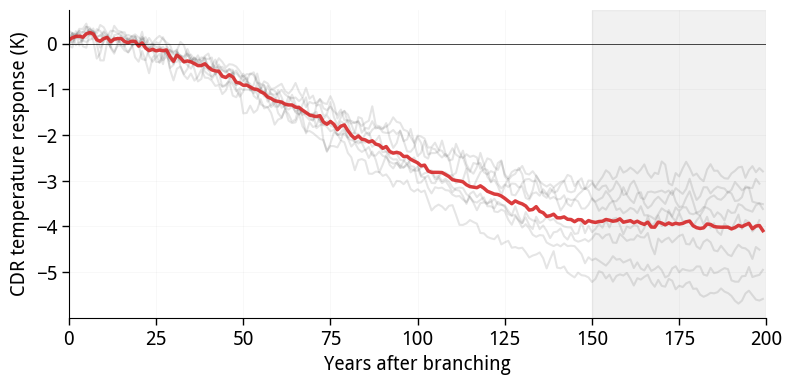

In [17]:
plt.figure(figsize=(9, 4))
for i in range(len(models_cdr)):
    plt.plot(cdr_values_temporal[i][:200], color='k', alpha=0.1)
plt.plot(np.nanmean(cdr_values_temporal, axis=0)[:200], color='tab:red', alpha=0.9, lw=2.5)
# plt.set_yticklabels([])
plt.axhline(0.0, color='k', ls='-', lw=0.5)
# plt.grid(alpha=0.1)
# plt.minorticks_on()
plt.xlabel('Years after branching')
plt.ylabel('CDR temperature response (K)')
plt.xlim(0, 200)
# plt.axvspan(10, 40, color='tab:blue', alpha=0.1)
# plt.axvspan(35, 65, color='tab:green', alpha=0.1)
# plt.axvspan(75, 105, color='tab:purple', alpha=0.1)
# plt.axvspan(105, 135, color='tab:red', alpha=0.1)
plt.axvspan(150, 200, color='tab:gray', alpha=0.1)
# plt.title('CDR')
plot_decorator()

In [18]:
cdr_changes = []
# cdr50_changes = []
# cdr90_changes = []
# cdr120_changes = []


for m in range(len(models_cdr)):
    branching_time = int(cdr_dat[models_cdr[m]].time[0].dt.year)
    if m == 2:
        branching_time = branching_time + 140
    if branching_time > 100 and branching_time < 1000:
        start_time = '0'+str(branching_time - 15)
        end_time = '0'+str(branching_time + 15)
    elif branching_time < 100:
        start_time = '00'+str(branching_time - 15)
        end_time = '00'+str(branching_time + 15)
    else:
        start_time = str(branching_time - 15)
        end_time = str(branching_time + 15)
    base = trans_dat[models_cdr[m]].sel(time = slice(start_time, end_time)).mean(('time', 'model'))

    # post25 = cdr_dat[models_cdr[m]].isel(time = slice(10, 40)).mean(('time', 'model'))
    # post50 = cdr_dat[models_cdr[m]].isel(time = slice(35, 65)).mean(('time', 'model'))
    # post90 = cdr_dat[models_cdr[m]].isel(time = slice(75, 105)).mean(('time', 'model'))
    # post120 = cdr_dat[models_cdr[m]].isel(time = slice(105, 135)).mean(('time', 'model'))
    post = cdr_dat[models_cdr[m]].isel(time = slice(150, 200)).mean(('time', 'model'))

    # cdr25_changes.append((post25 - base))
    # cdr50_changes.append((post50 - base))
    # cdr90_changes.append((post90 - base))
    # cdr120_changes.append((post120 - base))
    cdr_changes.append((post - base))
    print(f'Completed {m+1}')

Completed 1
Completed 2
Completed 3
Completed 4
Completed 5
Completed 6
Completed 7
Completed 8


In [19]:
xx, yy = np.meshgrid(cdr_changes[0].lon, cdr_changes[0].lat)

In [20]:
from matplotlib.colors import TwoSlopeNorm

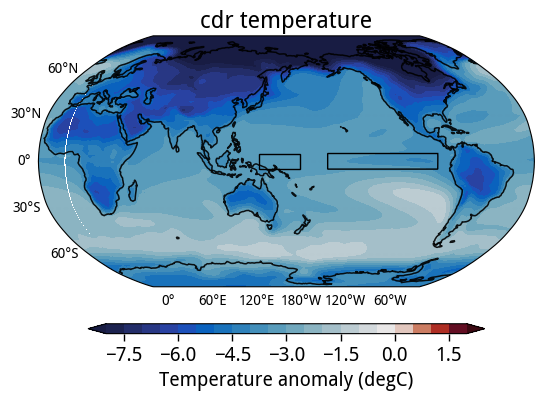

In [21]:
# plot_maps(xx, yy, [xr.concat(cdr25_changes, dim=models_cdr).mean('concat_dim'), xr.concat(cdr50_changes, dim=models_cdr).mean('concat_dim'), xr.concat(cdr90_changes, dim=models_cdr).mean('concat_dim')], titles=['cdr25', 'cdr50', 'cdr90'], labels=['']*3, cmap=cmocean.cm.balance, levels=np.arange(-0.6, 0.7, 0.1), cbar_label = 'Temperature anomaly (degC)', nrows=1, ncols=3, figsize=(12,3), land_mask_list = [], add_patch=True, add_patch_extra=False, cbar_orientation='horizontal', hatch_type = 'insig', proj=ccrs.Robinson(central_longitude=160))
ax = plt.axes(projection=ccrs.Robinson(central_longitude=160))
norm = TwoSlopeNorm(vmin=-8, vcenter=0, vmax=2)
cf = plt.contourf(xx, yy, xr.concat(cdr_changes, dim=models_cdr).mean('concat_dim'), transform=ccrs.PlateCarree(), cmap=cmocean.cm.balance, levels=np.linspace(-8, 2, 21), norm=norm, extend='both')
plot_background(ax)
plt.colorbar(cf, orientation='horizontal', aspect=40, pad=0.1, shrink=0.8, label='Temperature anomaly (degC)')
plt.title('cdr temperature')
ax.add_patch(mpatches.Rectangle(xy=[190, -5], width=80, height=10,
                                    facecolor='none', edgecolor='k',
                                    transform=ccrs.PlateCarree()))
ax.add_patch(mpatches.Rectangle(xy=[140, -5], width=30, height=10,
                                    facecolor='none', edgecolor='k',
                                    transform=ccrs.PlateCarree()))

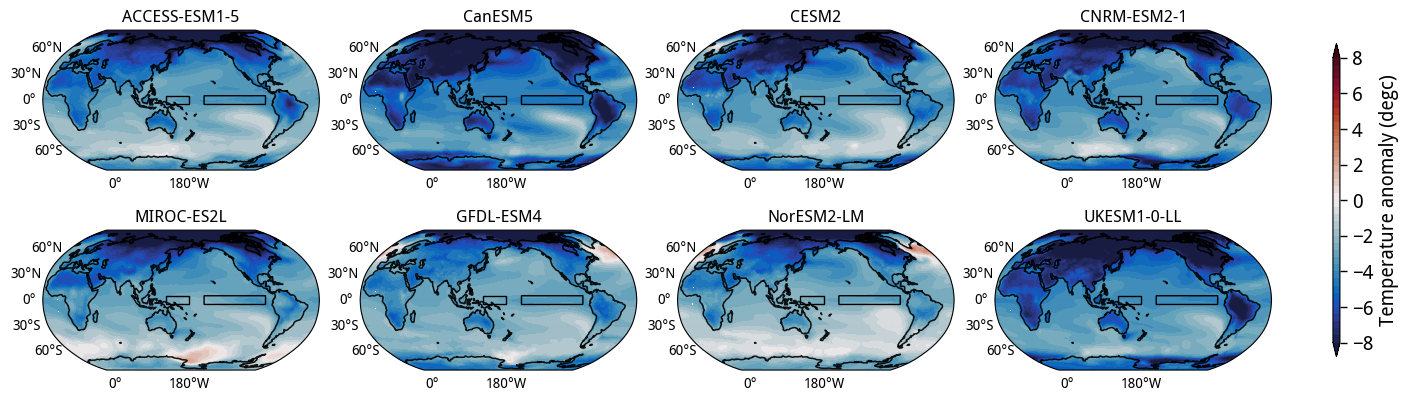

In [22]:
plot_maps(xx, yy, cdr_changes, titles=models_cdr, labels=['']*9, cmap=cmocean.cm.balance, levels=np.arange(-8, 8.4, 0.4), cbar_label = 'Temperature anomaly (degc)', nrows=2, ncols=4, figsize=(14,4), land_mask_list = [], add_patch=True, add_patch_extra=False, cbar_orientation='vertical', hatch_type = 'insig', proj=ccrs.Robinson(central_longitude=160))

In [102]:
# cdr25_values_global = []
# cdr50_values_global = []
# cdr90_values_global = []
# cdr120_values_global = []
cdr_values_global = []

for m in range(len(models_cdr)):
    branching_time = int(cdr_dat[models_cdr[m]].time[0].dt.year)
    if m == 2:
        branching_time = branching_time + 140
    if branching_time > 100 and branching_time < 1000:
        start_time = '0'+str(branching_time - 15)
        end_time = '0'+str(branching_time + 15)
    elif branching_time < 100:
        start_time = '00'+str(branching_time - 15)
        end_time = '00'+str(branching_time + 15)
    else:
        start_time = str(branching_time - 15)
        end_time = str(branching_time + 15)
    base = trans_dat[models_cdr[m]].sel(time = slice(start_time, end_time)).weighted(weights).mean(('lat', 'lon'))

    # post25 = cdr_dat[models_cdr[m]].isel(time = slice(10, 40)).weighted(weights).mean(('lat', 'lon'))
    # post50 = cdr_dat[models_cdr[m]].isel(time = slice(35, 65)).weighted(weights).mean(('lat', 'lon'))
    # post90 = cdr_dat[models_cdr[m]].isel(time = slice(75, 105)).weighted(weights).mean(('lat', 'lon'))
    # post120 = cdr_dat[models_cdr[m]].isel(time = slice(105, 135)).weighted(weights).mean(('lat', 'lon'))
    post = cdr_dat[models_cdr[m]].isel(time = slice(150, 200)).weighted(weights).mean(('lat', 'lon'))

    # cdr25_values_global.append((post25.mean('time') - base.mean('time')).to_numpy())
    # cdr50_values_global.append((post50.mean('time') - base.mean('time')).to_numpy())
    # cdr90_values_global.append((post90.mean('time') - base.mean('time')).to_numpy())
    # cdr120_values_global.append((post120.mean('time') - base.mean('time')).to_numpy())
    cdr_values_global.append((post.mean('time') - base.mean('time')).to_numpy())
    print(f'Completed {m+1}')

Completed 1
Completed 2
Completed 3
Completed 4
Completed 5
Completed 6
Completed 7
Completed 8


In [104]:
cdr_values_global

[array([-3.6422476]),
 array([-5.29886658]),
 array([-3.94236616]),
 array([-4.35552524]),
 array([-3.39747995]),
 array([-3.18044942]),
 array([-2.83473684]),
 array([-4.92100753])]

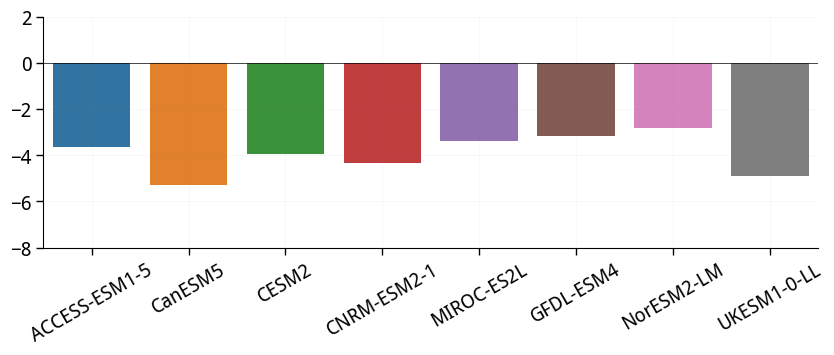

In [106]:
plt.figure(figsize=(10,3))
sns.barplot(cdr_values_global)
plt.gca().set_xticklabels(models_cdr)
plt.xticks(rotation=30)
plt.axhline(0.0, color='k', lw=0.5)
plt.ylim(-8, 2)
plot_decorator()

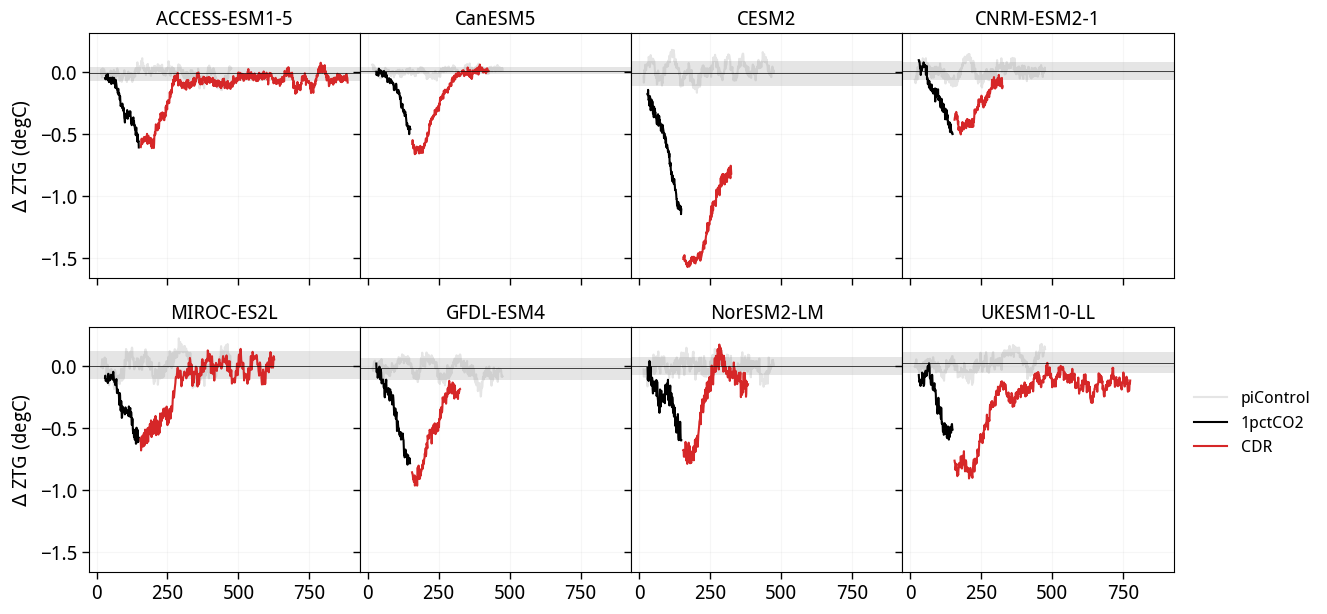

In [28]:
fig, axarr = plt.subplots(nrows=2, ncols=4, figsize=(14,7), constrained_layout=True, sharex=True, sharey=True)
axlist = axarr.flatten()
for i in range(len(axlist)):
    xdata0 = pic_dat[models_cdr[i]].time.dt.year
    sst_grad_pic = pic_dat[models_cdr[i]].sel(lat = slice(-5, 5), lon = slice(140, 170)).weighted(weights).mean(('lat', 'lon')).isel(time = slice(1, -1), model=0) - pic_dat[models_cdr[i]].sel(lat = slice(-5, 5), lon = slice(190, 270)).weighted(weights).mean(('lat', 'lon')).isel(time = slice(1, -1), model=0)
    try:
        axlist[i].plot((xdata0 - xdata0[0])[1:490], sst_grad_pic.isel(time = slice(1, 490)).rolling(time=30, center=True).mean('time'), color='tab:gray', label='piControl', alpha=0.2)
    except:
        axlist[i].plot((xdata0 - xdata0[0])[2:490], sst_grad_pic.rolling(time=30, center=True).mean('time'), color='tab:gray', label='piControl', alpha=0.2)
    axlist[i].axhspan(sst_grad_pic.isel(time = slice(1, -1)).rolling(time=30, center=True).mean('time').quantile(0.1, 'time'), sst_grad_pic.isel(time = slice(1, -1)).rolling(time=30, center=True).mean('time').quantile(0.9, 'time'), color='tab:gray', alpha=0.2, lw=0.0)
    #
    xdata0 = trans_dat[models_cdr[i]].time.dt.year
    sst_grad_trans = trans_dat[models_cdr[i]].sel(lat = slice(-5, 5), lon = slice(140, 170)).weighted(weights).mean(('lat', 'lon')).isel(time = slice(1, -1), model=0) - trans_dat[models_cdr[i]].sel(lat = slice(-5, 5), lon = slice(190, 270)).weighted(weights).mean(('lat', 'lon')).isel(time = slice(1, -1), model=0)
    axlist[i].plot((xdata0 - xdata0[0])[1:-1], sst_grad_trans.rolling(time=30, center=False).mean('time'), color='k', label='1pctCO2')
    #
    if i == 2:
        xdata = cdr_dat[models_cdr[i]].time.dt.year + 140
    else:
        xdata = cdr_dat[models_cdr[i]].time.dt.year
    sst_grad_stable = cdr_dat[models_cdr[i]].sel(lat = slice(-5, 5), lon = slice(140, 170)).weighted(weights).mean(('lat', 'lon')).isel(time = slice(1, -1), model=0) - cdr_dat[models_cdr[i]].sel(lat = slice(-5, 5), lon = slice(190, 270)).weighted(weights).mean(('lat', 'lon')).isel(time = slice(1, -1), model=0)
    axlist[i].plot((xdata - xdata0[0])[1:-1], sst_grad_stable.rolling(time=30, center=True).mean('time'), color='tab:red', ls='-', label='CDR')
    #
    #
    # axlist[i].set_xticks(np.arange(50, 450, 100))
    # axlist[i].set_yticklabels([])
    axlist[i].axhline(sst_grad_pic.isel(time = slice(1, -1)).rolling(time=30, center=True).mean('time').quantile(0.5, 'time'), color='k', ls='-', lw=0.5)
    axlist[i].grid(alpha=0.1)
    # axlist[i].set_title(models_cdr[i] + f' (n = {len(trans_dat[models_cdr[i]].model)})', fontsize=14)
    axlist[i].set_title(models_cdr[i], fontsize=14)

axlist[0].set_ylabel('$\Delta$ ZTG (degC)')
axlist[4].set_ylabel('$\Delta$ ZTG (degC)')
axlist[-1].legend(frameon=False, fontsize=12, bbox_to_anchor=(1.02, 0.8))

plt.subplots_adjust(wspace=0.0, hspace=0.2)
# plt.minorticks_on()
# plt.ylim(0.5,3.5)
# sns.despine()

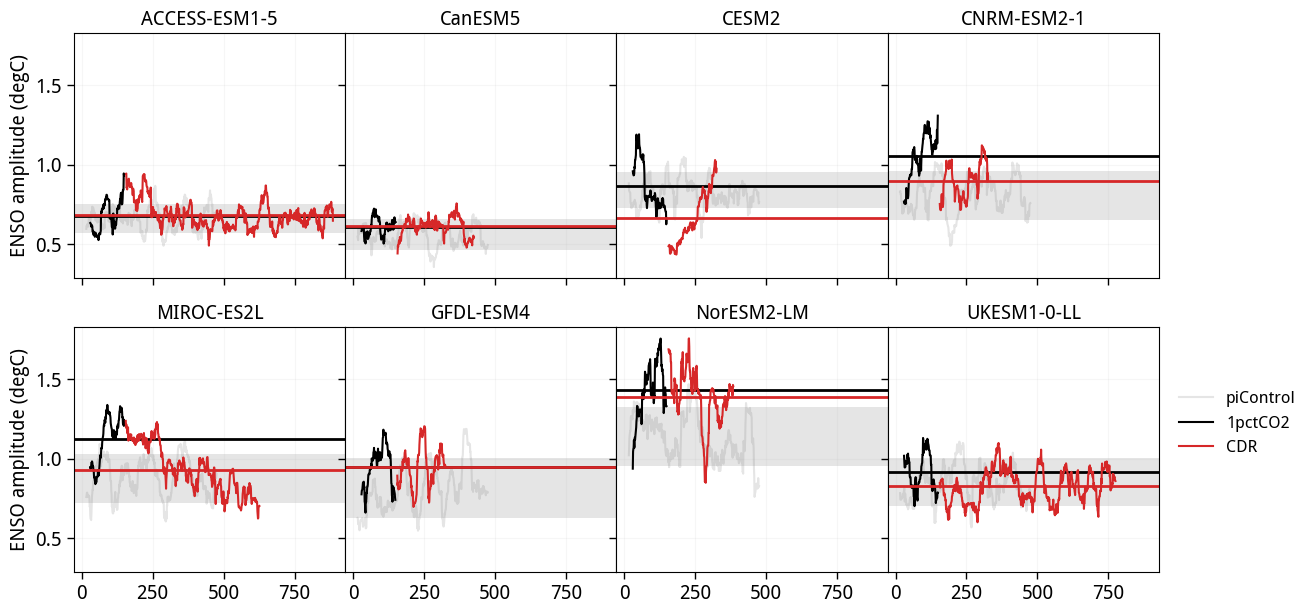

In [142]:
fig, axarr = plt.subplots(nrows=2, ncols=4, figsize=(14,7), constrained_layout=True, sharex=True, sharey=True)
axlist = axarr.flatten()
for i in range(len(axlist)):
    xdata0 = pic_dat[models_cdr[i]].time.dt.year
    nino34_pic = funcs.detrend_rolling_window(pic_dat[models_cdr[i]].sel(lat = slice(-5, 5), lon = slice(-170+360, -120+360)).weighted(weights).mean(('lat', 'lon')), window_size=15).isel(time = slice(1, -1), model=0)
    try:
        axlist[i].plot((xdata0 - xdata0[0])[1:490], nino34_pic.isel(time = slice(1,490)).rolling(time=30, center=True).std('time'), color='tab:gray', alpha=0.2, label='piControl')
    except:
        axlist[i].plot((xdata0 - xdata0[0])[2:490], nino34_pic.rolling(time=30, center=True).std('time'), color='tab:gray', alpha=0.2, label='piControl')
    # axlist[i].axhline(nino34_pic.isel(time = slice(1, 490)).rolling(time=30, center=True).std('time').mean('time'), color='tab:gray', lw=2.0)
    axlist[i].axhspan(nino34_pic.isel(time = slice(1, -1)).rolling(time=30, center=True).std('time').quantile(0.1, 'time'), nino34_pic.isel(time = slice(1, -1)).rolling(time=30, center=True).std('time').quantile(0.9, 'time'), color='tab:gray', alpha=0.2, lw=0.0)

    # axlist[i].axhspan(nino34_pic.isel(time = slice(1, -1)).rolling(time=30, center=True).std('time').quantile(0.1, 'time'), nino34_pic.isel(time = slice(1, -1)).rolling(time=30, center=True).std('time').quantile(0.9, 'time'), color='tab:gray', alpha=0.3)
    #
    xdata0 = trans_dat[models_cdr[i]].time.dt.year
    nino34_trans = funcs.detrend_rolling_window(trans_dat[models_cdr[i]].sel(lat = slice(-5, 5), lon = slice(-170+360, -120+360)).weighted(weights).mean(('lat', 'lon')), window_size=15).isel(time = slice(1, -1), model=0)
    axlist[i].plot((xdata0 - xdata0[0])[1:-1], nino34_trans.rolling(time=30, center=False).std('time'), color='k', label='1pctCO2')
    axlist[i].axhline(nino34_trans.rolling(time=30, center=False).std('time').mean('time'), color='k', lw=2.0)
    #
    if i == 2:
        xdata = cdr_dat[models_cdr[i]].time.dt.year + 140
    else:
        xdata = cdr_dat[models_cdr[i]].time.dt.year
    nino34_stable = funcs.detrend_rolling_window(cdr_dat[models_cdr[i]].sel(lat = slice(-5, 5), lon = slice(-170+360, -120+360)).weighted(weights).mean(('lat', 'lon')), window_size=15).isel(time = slice(1, -1), model=0)
    axlist[i].plot((xdata - xdata0[0])[1:-1], nino34_stable.rolling(time=30, center=True).std('time'), color='tab:red', ls='-', label='CDR')
    axlist[i].axhline(nino34_stable.rolling(time=30, center=True).std('time').mean('time'), color='tab:red', ls='-', lw=2.0)
    #
    # axlist[i].set_xticks(np.arange(0, 1000, 200))
    # axlist[i].set_yticklabels([])
    # axlist[i].axhline(0.0, color='k', ls='-', lw=0.5)
    axlist[i].grid(alpha=0.1)
    # axlist[i].set_title(models_cdr[i] + f' (n = {len(trans_dat[models_cdr[i]].model)})', fontsize=14)
    axlist[i].set_title(models_cdr[i], fontsize=14)

axlist[0].set_ylabel('ENSO amplitude (degC)')
axlist[4].set_ylabel('ENSO amplitude (degC)')
axlist[-1].legend(frameon=False, fontsize=12, bbox_to_anchor=(1.02, 0.8))

plt.subplots_adjust(wspace=0.0, hspace=0.2)
# plt.minorticks_on()
# plt.ylim(0.5,3.5)
# sns.despine()

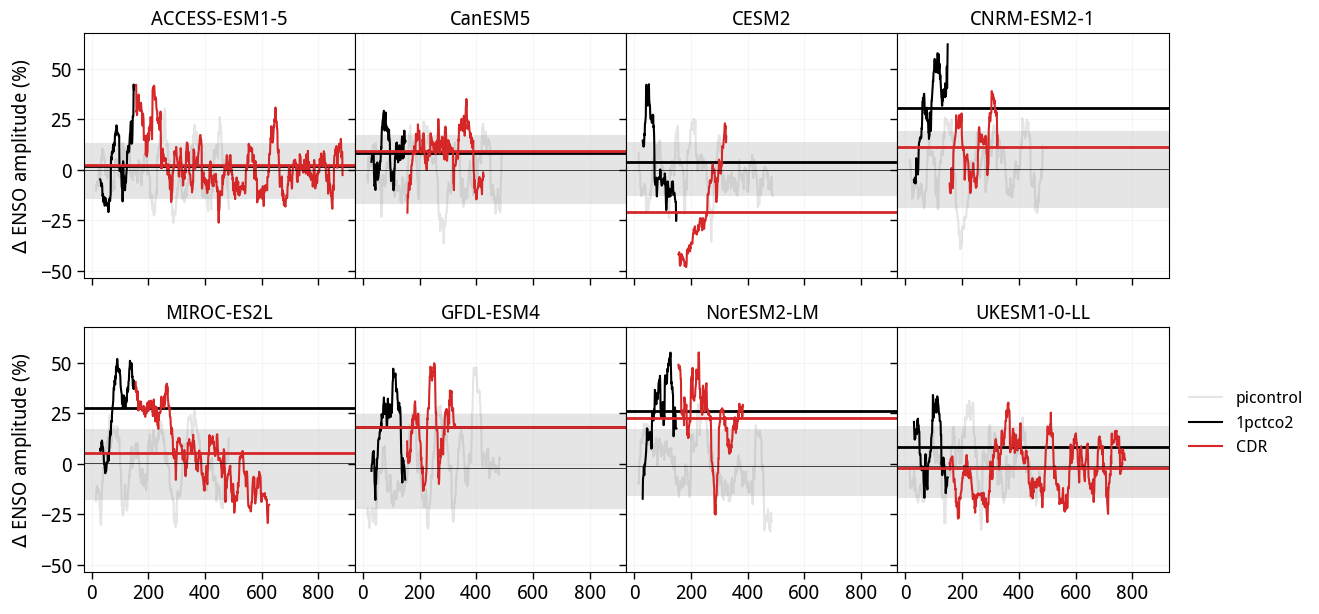

In [146]:
fig, axarr = plt.subplots(nrows=2, ncols=4, figsize=(14,7), constrained_layout=True, sharex=True, sharey=True)
axlist = axarr.flatten()
for i in range(len(axlist)):
    xdata0 = pic_dat[models_cdr[i]].time.dt.year
    rolling_mag_pic = funcs.detrend_rolling_window(pic_dat[models_cdr[i]].sel(lat = slice(-5, 5), lon = slice(-170+360, -120+360)).weighted(weights).mean(('lat', 'lon')), window_size=15).isel(time = slice(1, -1), model=0).rolling(time = 30, center=True).std('time')
    pic_change = (rolling_mag_pic/rolling_mag_pic.mean('time') - 1)*100
    try:
        axlist[i].plot((xdata0 - xdata0[0])[1:490], pic_change.isel(time = slice(1, 490)), color='tab:gray', label='picontrol', alpha=0.2)
    except:
        axlist[i].plot((xdata0 - xdata0[0])[2:490], pic_change, color='tab:gray', label='picontrol', alpha=0.2)
    axlist[i].axhspan(pic_change.isel(time = slice(1, -1)).quantile(0.1, 'time'), pic_change.isel(time = slice(1, -1)).quantile(0.9, 'time'), color='tab:gray', alpha=0.2, lw=0.0)
    # bplot = axlist[i].boxplot(pic_change.dropna('time'), boxprops=dict(color='k'), meanline=false, widths=8, patch_artist=True, medianprops=dict(color='k'), showfliers=false, whis=[5, 95], positions=[-20])
    # for patch, color in zip(bplot['boxes'], ['k']):
        # patch.set_facecolor(color)

    # axlist[i].axhspan(nino34_pic.isel(time = slice(1, -1)).rolling(time=30, center=True).std('time').quantile(0.1, 'time'), nino34_pic.isel(time = slice(1, -1)).rolling(time=30, center=True).std('time').quantile(0.9, 'time'), color='tab:gray', alpha=0.3)
    #
    xdata0 = trans_dat[models_cdr[i]].time.dt.year
    rolling_mag_trans = funcs.detrend_rolling_window(trans_dat[models_cdr[i]].sel(lat = slice(-5, 5), lon = slice(-170+360, -120+360)).weighted(weights).mean(('lat', 'lon')), window_size=15).isel(time = slice(1, -1), model=0).rolling(time = 30, center=False).std('time')
    trans_change = (rolling_mag_trans/rolling_mag_pic.mean('time') - 1)*100
    axlist[i].plot((xdata0 - xdata0[0])[1:-1], trans_change, color='k', label='1pctco2')
    # axlist[i].plot([(xdata0 - xdata0[0])[30], (xdata0 - xdata0[0])[-30]], [trans_change.dropna('time')[1], trans_change.dropna('time')[-1]], color='k')
    axlist[i].axhline(trans_change.mean('time'), color='k', lw=2.0)
    # #
    #
    if i == 2:
        xdata = cdr_dat[models_cdr[i]].time.dt.year + 140
    else:
        xdata = cdr_dat[models_cdr[i]].time.dt.year
    rolling_mag_stable = funcs.detrend_rolling_window(cdr_dat[models_cdr[i]].sel(lat = slice(-5, 5), lon = slice(-170+360, -120+360)).weighted(weights).mean(('lat', 'lon')), window_size=15).isel(time = slice(1, -1), model=0).rolling(time = 30, center=True).std('time')
    stable_change = (rolling_mag_stable/rolling_mag_pic.mean('time') - 1)*100
    axlist[i].plot((xdata - xdata0[0])[1:-1], stable_change, color='tab:red', label='CDR')
    axlist[i].axhline(stable_change.mean('time'), color='tab:red', lw=2.0)
    #
    axlist[i].set_xticks(np.arange(0, 1000, 200))
    # axlist[i].set_xticklabels([str(x) for x in np.arange(50, 450, 100)])
    axlist[i].axhline(pic_change.isel(time = slice(1, -1)).quantile(0.5, 'time'), color='k', lw=0.5)
    # axlist[i].set_yticklabels([])
    # axlist[i].axhline(0.0, color='k', ls='-', lw=0.5)
    axlist[i].grid(alpha=0.1)
    # axlist[i].set_title(models_cdr[i] + f' (n = {len(trans_dat[models_cdr[i]].model)})', fontsize=14)
    axlist[i].set_title(models_cdr[i], fontsize=14)

axlist[0].set_ylabel('$\Delta$ ENSO amplitude (%)')
axlist[4].set_ylabel('$\Delta$ ENSO amplitude (%)')
axlist[-1].legend(frameon=False, fontsize=12, bbox_to_anchor=(1.02, 0.8))

plt.subplots_adjust(wspace=0.0, hspace=0.2)
# plt.minorticks_on()
# plt.ylim(0.5,3.5)
# sns.despine()

In [16]:
def plot_dist_inset(ax, val, yval, color, dim=("time")):
    # Error bars (0.1, 0.5, 0.9 quantiles)
    q10 = val.quantile(0.1, dim=dim)
    q50 = val.quantile(0.5, dim=dim)
    q90 = val.quantile(0.9, dim=dim)
    
    ax.errorbar(
        x=q50, y=yval,
        xerr=[[q50 - q10], [q90 - q50]],
        fmt="o", color=color, mfc="white", mec=color,
        capsize=4, lw=2.0, ms=6, mew=1.2, zorder=5
    )
    

(0.0, 0.07)

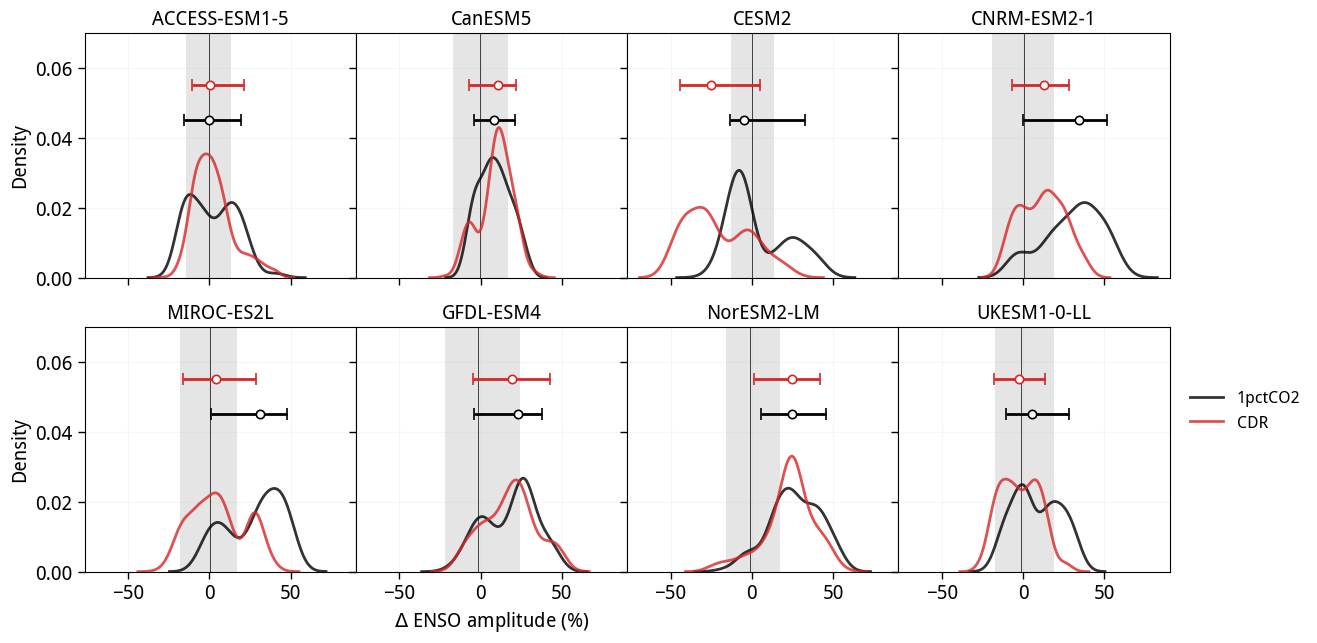

In [152]:
fig, axarr = plt.subplots(nrows=2, ncols=4, figsize=(14,7), constrained_layout=True, sharex=True, sharey=True)
axlist = axarr.flatten()
for i in range(len(axlist)):
    # xdata0 = pic_dat[models_cdr[i]].time.dt.year
    rolling_mag_pic = funcs.detrend_rolling_window(pic_dat[models_cdr[i]].sel(lat = slice(-5, 5), lon = slice(-170+360, -120+360)).weighted(weights).mean(('lat', 'lon')), window_size=15).isel(time = slice(1, -1), model=0).rolling(time = 30, center=True).std('time')
    pic_change = (rolling_mag_pic/rolling_mag_pic.mean('time') - 1)*100
    axlist[i].axvspan(pic_change.isel(time = slice(1, -1)).quantile(0.1, 'time'), pic_change.isel(time = slice(1, -1)).quantile(0.9, 'time'), color='tab:gray', alpha=0.2, lw=0.0)
    axlist[i].axvline(pic_change.isel(time = slice(1, -1)).quantile(0.5, 'time'), color='k', lw=0.5)
    # bplot = axlist[i].boxplot(pic_change.dropna('time'), boxprops=dict(color='k'), meanline=False, widths=8, patch_artist=True, medianprops=dict(color='k'), showfliers=False, whis=[5, 95], positions=[-20])
    # for patch, color in zip(bplot['boxes'], ['k']):
        # patch.set_facecolor(color)

    # axlist[i].axhspan(nino34_pic.isel(time = slice(1, -1)).rolling(time=30, center=True).std('time').quantile(0.1, 'time'), nino34_pic.isel(time = slice(1, -1)).rolling(time=30, center=True).std('time').quantile(0.9, 'time'), color='tab:gray', alpha=0.3)
    #
    # xdata0 = trans_dat[models_cdr[i]].time.dt.year
    rolling_mag_trans = funcs.detrend_rolling_window(trans_dat[models_cdr[i]].sel(lat = slice(-5, 5), lon = slice(-170+360, -120+360)).weighted(weights).mean(('lat', 'lon')), window_size=15).isel(time = slice(1, -1), model=0).rolling(time = 30, center=True).std('time')
    trans_change = (rolling_mag_trans/rolling_mag_pic.mean('time') - 1)*100
    sns.kdeplot(trans_change.to_numpy().flatten(), alpha=0.8, color='k', lw=2.0, label='1pctCO2', ax=axlist[i])
    plot_dist_inset(axlist[i], trans_change, 0.045, 'k')
    # #
    #
    # xdata = cdr_dat[models_cdr[i]].time.dt.year
    rolling_mag_stable = funcs.detrend_rolling_window(cdr_dat[models_cdr[i]].sel(lat = slice(-5, 5), lon = slice(-170+360, -120+360)).weighted(weights).mean(('lat', 'lon')), window_size=15).isel(time = slice(1, -1), model=0).rolling(time = 30, center=True).std('time')
    stable_change = (rolling_mag_stable/rolling_mag_pic.mean('time') - 1)*100
    sns.kdeplot(stable_change.to_numpy().flatten(), alpha=0.8, color='tab:red', lw=2.0, label='CDR', ax=axlist[i])
    plot_dist_inset(axlist[i], stable_change, 0.055, 'tab:red')

    # axlist[i].plot([(xdata - xdata0[0])[30], (xdata - xdata0[0])[-30]], [stable_change.dropna('time')[1], stable_change.dropna('time')[-1]], color='tab:blue')
    #
    # axlist[i].set_xticks(np.arange(50, 450, 100))
    # axlist[i].set_xticklabels([str(x) for x in np.arange(50, 450, 100)])
    # axlist[i].set_yticklabels([])
    # axlist[i].axhline(0.0, color='k', ls='-', lw=0.5)
    axlist[i].grid(alpha=0.1)
    axlist[i].set_ylabel('')
    # axlist[i].set_title(models_cdr[i] + f' (n = {len(trans_dat[models_cdr[i]].model)})', fontsize=14)
    axlist[i].set_title(models_cdr[i], fontsize=14)


axlist[5].set_xlabel('$\Delta$ ENSO amplitude (%)')
axlist[0].set_ylabel('Density')
axlist[4].set_ylabel('Density')
axlist[-1].legend(frameon=False, fontsize=12, bbox_to_anchor=(1.02, 0.8))

plt.subplots_adjust(wspace=0.0, hspace=0.2)
# plt.minorticks_on()
plt.ylim(0, 0.07)
# sns.despine()

(0.0, 10.0)

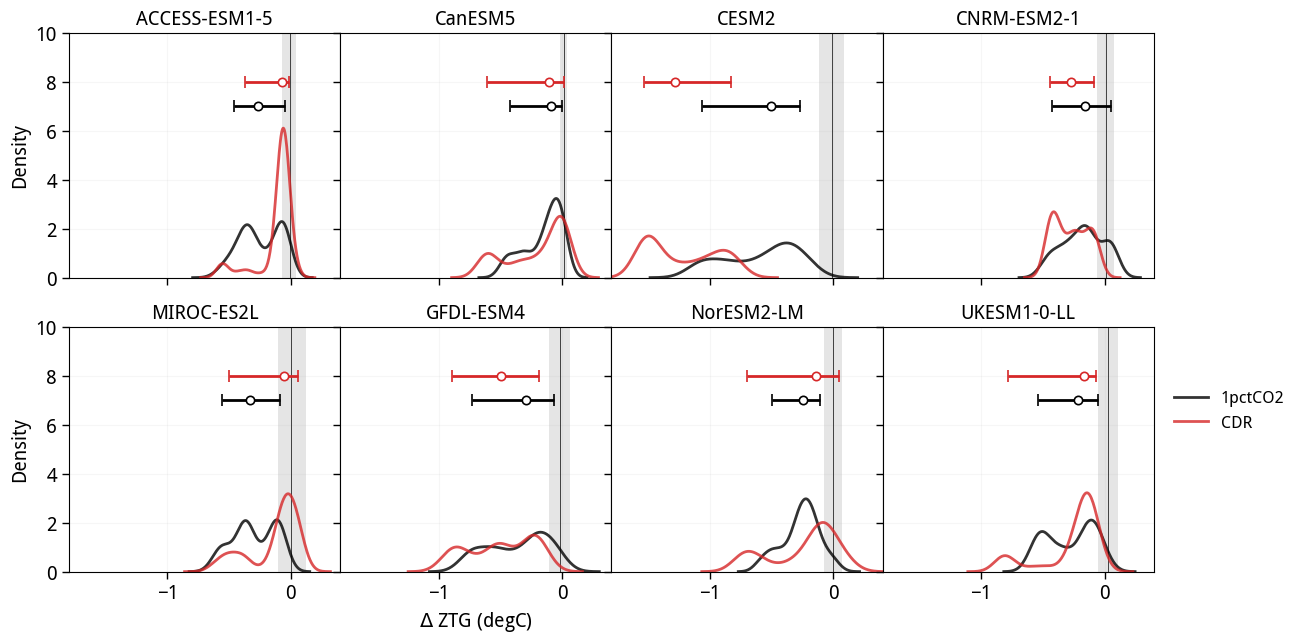

In [17]:
fig, axarr = plt.subplots(nrows=2, ncols=4, figsize=(14,7), constrained_layout=True, sharex=True, sharey=True)
axlist = axarr.flatten()
for i in range(len(axlist)):
    xdata0 = pic_dat[models_cdr[i]].time.dt.year
    sst_grad_pic = pic_dat[models_cdr[i]].sel(lat = slice(-5, 5), lon = slice(140, 170)).weighted(weights).mean(('lat', 'lon')).isel(time = slice(1, -1), model=0) - pic_dat[models_cdr[i]].sel(lat = slice(-5, 5), lon = slice(190, 270)).weighted(weights).mean(('lat', 'lon')).isel(time = slice(1, -1), model=0)
    axlist[i].axvspan(sst_grad_pic.isel(time = slice(1, -1)).rolling(time=30, center=True).mean('time').quantile(0.1, 'time'), sst_grad_pic.isel(time = slice(1, -1)).rolling(time=30, center=True).mean('time').quantile(0.9, 'time'), color='tab:gray', alpha=0.2, lw=0.0)
    axlist[i].axvline(sst_grad_pic.isel(time = slice(1, -1)).rolling(time=30, center=True).mean('time').quantile(0.5, 'time'), color='k', ls='-', lw=0.5)
    #
    xdata0 = trans_dat[models_cdr[i]].time.dt.year
    sst_grad_trans = trans_dat[models_cdr[i]].sel(lat = slice(-5, 5), lon = slice(140, 170)).weighted(weights).mean(('lat', 'lon')).isel(time = slice(1, -1), model=0) - trans_dat[models_cdr[i]].sel(lat = slice(-5, 5), lon = slice(190, 270)).weighted(weights).mean(('lat', 'lon')).isel(time = slice(1, -1), model=0)
    sns.kdeplot(sst_grad_trans.rolling(time=30, center=True).mean('time').to_numpy().flatten(), alpha=0.8, color='k', lw=2.0, label='1pctCO2', ax=axlist[i])
    plot_dist_inset(axlist[i], sst_grad_trans.rolling(time=30, center=True).mean('time'), 7, 'k')
    #
    xdata = cdr_dat[models_cdr[i]].time.dt.year
    sst_grad_stable = cdr_dat[models_cdr[i]].sel(lat = slice(-5, 5), lon = slice(140, 170)).weighted(weights).mean(('lat', 'lon')).isel(time = slice(1, -1), model=0) - cdr_dat[models_cdr[i]].sel(lat = slice(-5, 5), lon = slice(190, 270)).weighted(weights).mean(('lat', 'lon')).isel(time = slice(1, -1), model=0)
    sns.kdeplot(sst_grad_stable.rolling(time=30, center=True).mean('time').to_numpy().flatten(), alpha=0.8, color='tab:red', lw=2.0, label='CDR', ax=axlist[i])
    plot_dist_inset(axlist[i], sst_grad_stable.rolling(time=30, center=True).mean('time'), 8, 'tab:red')
    #
    #
    # axlist[i].set_yticklabels([])
    axlist[i].grid(alpha=0.1)
    axlist[i].set_ylabel('')
    # axlist[i].set_title(models_cdr[i] + f' (n = {len(trans_dat[models_cdr[i]].model)})', fontsize=14)
    axlist[i].set_title(models_cdr[i], fontsize=14)

axlist[5].set_xlabel('$\Delta$ ZTG (degC)')
axlist[0].set_ylabel('Density')
axlist[4].set_ylabel('Density')
axlist[-1].legend(frameon=False, fontsize=12, bbox_to_anchor=(1.02, 0.8))

plt.subplots_adjust(wspace=0.0, hspace=0.2)
# plt.minorticks_on()
plt.xlim(-1.8, 0.4)
plt.ylim(0, 10)
# sns.despine()

In [18]:
nino34_arr = []
sst_grad_arr = []
gmst_arr = []
for i in range(len(pic_dat)):
    nino34 = funcs.detrend_rolling_window(pic_dat[models_cdr[i]].sel(lat = slice(-5, 5), lon = slice(-170+360, -120+360)).weighted(weights).mean(('lat', 'lon')), window_size=15).isel(time = slice(1, -1), model=0).drop('model')
    sst_grad = (pic_dat[models_cdr[i]].sel(lat = slice(-5, 5), lon = slice(140, 170)).weighted(weights).mean(('lat', 'lon')).isel(time = slice(1, -1), model=0) - pic_dat[models_cdr[i]].sel(lat = slice(-5, 5), lon = slice(190, 270)).weighted(weights).mean(('lat', 'lon')).isel(time = slice(1, -1), model=0)).rolling(time = 30, center=True).mean('time').drop('model')
    gmst = (pic_dat[models_cdr[i]].weighted(weights).mean(('lat', 'lon'))).isel(time = slice(1, -1), model=0).drop('model')
    try:
        nino34['time'] = xr.cftime_range('0100-01-01', f'0{len(nino34.time.dt.year) + 99}-01-01', freq='YS')
        sst_grad['time'] = xr.cftime_range('0100-01-01', f'0{len(sst_grad.time.dt.year) + 99}-01-01', freq='YS')
        gmst['time'] = xr.cftime_range('0100-01-01', f'0{len(gmst.time.dt.year) + 99}-01-01', freq='YS')
    except ValueError:
        nino34['time'] = xr.cftime_range('0100-01-01', f'{len(nino34.time.dt.year) + 99}-01-01', freq='YS')
        sst_grad['time'] = xr.cftime_range('0100-01-01', f'{len(sst_grad.time.dt.year) + 99}-01-01', freq='YS')
        gmst['time'] = xr.cftime_range('0100-01-01', f'{len(gmst.time.dt.year) + 99}-01-01', freq='YS')
    nino34_arr.append(nino34)
    sst_grad_arr.append(sst_grad)
    gmst_arr.append(gmst)
    print(f'done {i}', end='\r')

nino34_pic = xr.concat(nino34_arr, dim=models_cdr, coords='minimal', compat='override').rename(concat_dim = 'model')
sst_grad_pic = xr.concat(sst_grad_arr, dim=models_cdr, coords='minimal', compat='override').rename(concat_dim = 'model')
gmst_pic = xr.concat(gmst_arr, dim=models_cdr, coords='minimal', compat='override').rename(concat_dim = 'model')

In [19]:
nino34_arr = []
sst_grad_arr = []
gmst_arr = []
for i in range(len(trans_dat)):
    nino34 = funcs.detrend_rolling_window(trans_dat[models_cdr[i]].sel(lat = slice(-5, 5), lon = slice(-170+360, -120+360)).weighted(weights).mean(('lat', 'lon')), window_size=15).isel(time = slice(1, -1), model=0).drop('model')
    sst_grad = (trans_dat[models_cdr[i]].sel(lat = slice(-5, 5), lon = slice(140, 170)).weighted(weights).mean(('lat', 'lon')).isel(time = slice(1, -1), model=0) - trans_dat[models_cdr[i]].sel(lat = slice(-5, 5), lon = slice(190, 270)).weighted(weights).mean(('lat', 'lon')).isel(time = slice(1, -1), model=0)).rolling(time = 30, center=False).mean('time').drop('model')
    gmst = (trans_dat[models_cdr[i]]).weighted(weights).mean(('lat', 'lon')).isel(time = slice(1, -1), model=0).drop('model')
    try:
        nino34['time'] = xr.cftime_range('0100-01-01', f'0{len(nino34.time.dt.year) + 99}-01-01', freq='YS')
        sst_grad['time'] = xr.cftime_range('0100-01-01', f'0{len(sst_grad.time.dt.year) + 99}-01-01', freq='YS')
        gmst['time'] = xr.cftime_range('0100-01-01', f'0{len(gmst.time.dt.year) + 99}-01-01', freq='YS')
    except ValueError:
        nino34['time'] = xr.cftime_range('0100-01-01', f'{len(nino34.time.dt.year) + 99}-01-01', freq='YS')
        sst_grad['time'] = xr.cftime_range('0100-01-01', f'{len(sst_grad.time.dt.year) + 99}-01-01', freq='YS')
        gmst['time'] = xr.cftime_range('0100-01-01', f'{len(gmst.time.dt.year) + 99}-01-01', freq='YS')
    nino34_arr.append(nino34)
    sst_grad_arr.append(sst_grad)
    gmst_arr.append(gmst)
    print(f'done {i}', end='\r')

nino34_trans = xr.concat(nino34_arr, dim=models_cdr, coords='minimal', compat='override').rename(concat_dim = 'model')
sst_grad_trans = xr.concat(sst_grad_arr, dim=models_cdr, coords='minimal', compat='override').rename(concat_dim = 'model')
gmst_trans = xr.concat(gmst_arr, dim=models_cdr, coords='minimal', compat='override').rename(concat_dim = 'model')

In [20]:
nino34_arr = []
sst_grad_arr = []
gmst_arr = []
brch_year1000 = []
for i in range(len(cdr_dat)):
    nino34 = funcs.detrend_rolling_window(cdr_dat[models_cdr[i]].sel(lat = slice(-5, 5), lon = slice(-170+360, -120+360)).weighted(weights).mean(('lat', 'lon')), window_size=15).isel(time = slice(1, -1), model=0).drop('model')
    sst_grad = (cdr_dat[models_cdr[i]].sel(lat = slice(-5, 5), lon = slice(140, 170)).weighted(weights).mean(('lat', 'lon')).isel(time = slice(1, -1), model=0) - cdr_dat[models_cdr[i]].sel(lat = slice(-5, 5), lon = slice(190, 270)).weighted(weights).mean(('lat', 'lon')).isel(time = slice(1, -1), model=0)).rolling(time = 30, center=True).mean('time').drop('model')
    gmst = (cdr_dat[models_cdr[i]]).weighted(weights).mean(('lat', 'lon')).isel(time = slice(1, -1), model=0).drop('model')
    zero_year = float((trans_dat[models_cdr[i]]).time.dt.year[0])
    brch_year = float(sst_grad.time.dt.year[0]) - zero_year
    try:
        nino34['time'] = xr.cftime_range('0100-01-01', f'0{len(nino34.time.dt.year) + 99}-01-01', freq='YS')
        sst_grad['time'] = xr.cftime_range('0100-01-01', f'0{len(sst_grad.time.dt.year) + 99}-01-01', freq='YS')
        gmst['time'] = xr.cftime_range('0100-01-01', f'0{len(gmst.time.dt.year) + 99}-01-01', freq='YS')
    except ValueError:
        nino34['time'] = xr.cftime_range('0100-01-01', f'{len(nino34.time.dt.year) + 99}-01-01', freq='YS')
        gmst['time'] = xr.cftime_range('0100-01-01', f'{len(gmst.time.dt.year) + 99}-01-01', freq='YS')
    nino34_arr.append(nino34)
    sst_grad_arr.append(sst_grad)
    gmst_arr.append(gmst)
    brch_year1000.append(brch_year)
    print(f'done {i}', end='\r')

nino34_cdr = xr.concat(nino34_arr, dim=models_cdr, coords='minimal', compat='override').rename(concat_dim = 'model')
sst_grad_cdr = xr.concat(sst_grad_arr, dim=models_cdr, coords='minimal', compat='override').rename(concat_dim = 'model')
gmst_cdr = xr.concat(gmst_arr, dim=models_cdr, coords='minimal', compat='override').rename(concat_dim = 'model')

In [21]:
rolling_mag_pic = nino34_pic.rolling(time = 30, center=True).std('time')
rolling_mag_trans = nino34_trans.rolling(time = 30, center=False).std('time')
rolling_mag_cdr = nino34_cdr.rolling(time = 30, center=True).std('time')

In [22]:
pic_change = (rolling_mag_pic/rolling_mag_pic.mean('time') - 1)*100
trans_change = (rolling_mag_trans/rolling_mag_pic.mean('time') - 1)*100
cdr_change = (rolling_mag_cdr/rolling_mag_pic.mean('time') - 1)*100

In [23]:
nino34_cdr

<xarray.DataArray 'tas' (model: 8, time: 759)>
array([[ 0.21523647,  2.36197794, -0.32530877, ..., -0.91519131,
         0.34292783,  0.0899066 ],
       [ 0.28985145, -0.57582681, -0.52338829, ...,         nan,
                nan,         nan],
       [ 0.23448091,  0.50262961, -0.73852061, ...,         nan,
                nan,         nan],
       ...,
       [-2.03333486,  0.80103697, -1.61792438, ...,         nan,
                nan,         nan],
       [-2.10095861, -1.43296074,  0.79540808, ...,         nan,
                nan,         nan],
       [-1.24105782,  0.11724141, -0.20308609, ...,         nan,
                nan,         nan]])
Coordinates:
  * time                (time) object 0100-01-01 00:00:00 ... 0858-01-01 00:0...
    height              (time) float64 2.0 2.0 2.0 2.0 2.0 ... 2.0 2.0 2.0 2.0
    latitude_longitude  (time) float64 nan nan nan nan nan ... nan nan nan nan
    month               (time) int64 6 6 6 6 6 6 6 6 6 6 ... 6 6 6 6 6 6 6 6 6 6
  * model               (model) object 'ACCESS-ESM1-5' ... 'UKESM1-0-LL'

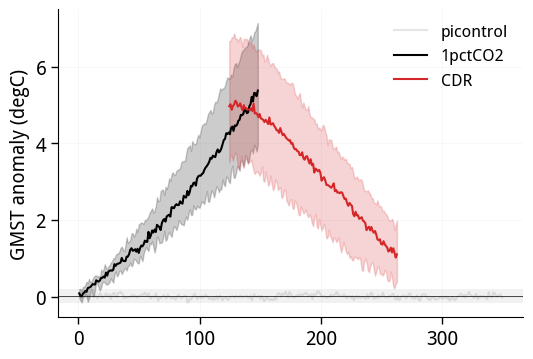

In [24]:
plt.figure(figsize=(6,4))
xdata0 = gmst_pic.time.dt.year
plt.plot((xdata0 - xdata0[0])[1:350], gmst_pic.isel(time = slice(1, 350)).quantile(0.5, 'model'), color='tab:gray', label='picontrol', alpha=0.2)
plt.axhspan(gmst_pic.isel(time = slice(1, -1)).quantile(0.1, dim=(('time', 'model'))), gmst_pic.isel(time = slice(1, -1)).quantile(0.9, dim=(('time', 'model'))), color='tab:gray', alpha=0.1, lw=0.0)
plt.axhline(gmst_pic.quantile(0.5, dim=(('time', 'model'))), color='k', lw=0.5)
#
xdata0 = gmst_trans.time.dt.year
plt.plot((xdata0 - xdata0[0])[1:-1], gmst_trans.isel(time = slice(1, -1)).quantile(0.5, 'model'), color='k', label='1pctCO2')
plt.fill_between((xdata0 - xdata0[0])[1:-1], gmst_trans.isel(time = slice(1, -1)).quantile(0.1, 'model'), gmst_trans.isel(time = slice(1, -1)).quantile(0.9, 'model'), color='k', alpha=0.2)
#
xdata = gmst_cdr.time.dt.year + np.mean(brch_year1000)
plt.plot((xdata - xdata0[0])[1:140], gmst_cdr.isel(time = slice(1, 140)).quantile(0.5, 'model'), color='tab:red', label='CDR')
plt.fill_between((xdata - xdata0[0]).isel(time = slice(1, 140)), gmst_cdr.isel(time = slice(1, 140)).quantile(0.1, 'model'), gmst_cdr.isel(time = slice(1, 140)).quantile(0.9, 'model'), color='tab:red', alpha=0.2)
#

plt.ylabel('GMST anomaly (degC)')
plt.legend(frameon=False, fontsize=12, loc='upper right')
plot_decorator()

# plt.minorticks_on()
# # plt.ylim(0.5,3.5)
# # sns.despine()

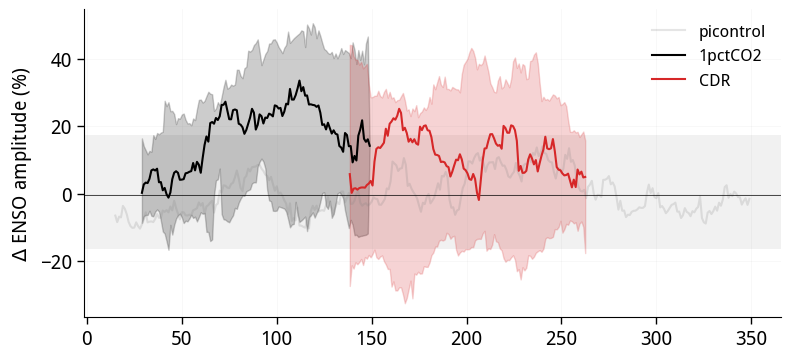

In [25]:
plt.figure(figsize=(9,4))
xdata0 = pic_change.time.dt.year
plt.plot((xdata0 - xdata0[0])[1:350], pic_change.isel(time = slice(1, 350)).quantile(0.5, 'model'), color='tab:gray', label='picontrol', alpha=0.2)
plt.axhspan(pic_change.isel(time = slice(1, -1)).quantile(0.1, dim=(('time', 'model'))), pic_change.isel(time = slice(1, -1)).quantile(0.9, dim=(('time', 'model'))), color='tab:gray', alpha=0.1, lw=0.0)
plt.axhline(pic_change.quantile(0.5, dim=(('time', 'model'))), color='k', lw=0.5)
#
xdata0 = trans_change.time.dt.year
plt.plot((xdata0 - xdata0[0])[1:300], trans_change.isel(time = slice(1, 300)).quantile(0.5, 'model'), color='k', label='1pctCO2')
plt.fill_between((xdata0 - xdata0[0])[1:300], trans_change.isel(time = slice(1, 300)).quantile(0.1, 'model'), trans_change.isel(time = slice(1, 300)).quantile(0.9, 'model'), color='k', alpha=0.2)
#
xdata = cdr_change.time.dt.year + np.mean(brch_year1000)
plt.plot((xdata - xdata0[0])[1:140], cdr_change.isel(time = slice(1, 140)).quantile(0.5, 'model'), color='tab:red', label='CDR')
plt.fill_between((xdata - xdata0[0]).isel(time = slice(1, 140)), cdr_change.isel(time = slice(1, 140)).quantile(0.1, 'model'), cdr_change.isel(time = slice(1, 140)).quantile(0.9, 'model'), color='tab:red', alpha=0.2)
#

plt.ylabel('$\Delta$ ENSO amplitude (%)')
plt.legend(frameon=False, fontsize=12, loc='upper right')
plot_decorator()

# plt.minorticks_on()
# # plt.ylim(0.5,3.5)
# # sns.despine()

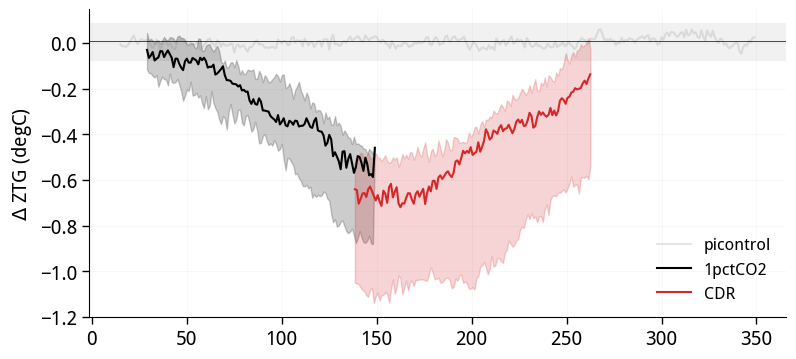

In [26]:
plt.figure(figsize=(9,4))
xdata0 = sst_grad_pic.time.dt.year
plt.plot((xdata0 - xdata0[0])[1:350], sst_grad_pic.isel(time = slice(1, 350)).quantile(0.5, 'model'), color='tab:gray', label='picontrol', alpha=0.2)
plt.axhspan(sst_grad_pic.isel(time = slice(1, -1)).quantile(0.1, dim=(('time', 'model'))), sst_grad_pic.isel(time = slice(1, -1)).quantile(0.9, dim=(('time', 'model'))), color='tab:gray', alpha=0.1, lw=0.0)
plt.axhline(sst_grad_pic.quantile(0.5, dim=(('time', 'model'))), color='k', lw=0.5)
#
xdata0 = sst_grad_trans.time.dt.year
plt.plot((xdata0 - xdata0[0])[1:300], sst_grad_trans.isel(time = slice(1, 300)).quantile(0.5, 'model'), color='k', label='1pctCO2')
plt.fill_between((xdata0 - xdata0[0])[1:300], sst_grad_trans.isel(time = slice(1, 300)).quantile(0.1, 'model'), sst_grad_trans.isel(time = slice(1, 300)).quantile(0.9, 'model'), color='k', alpha=0.2)
#
xdata = sst_grad_cdr.time.dt.year + np.mean(brch_year1000)
plt.plot((xdata - xdata0[0])[1:140], sst_grad_cdr.isel(time = slice(1, 140)).quantile(0.5, 'model'), color='tab:red', label='CDR')
plt.fill_between((xdata - xdata0[0]).isel(time = slice(1, 140)), sst_grad_cdr.isel(time = slice(1, 140)).quantile(0.1, 'model'), sst_grad_cdr.isel(time = slice(1, 140)).quantile(0.9, 'model'), color='tab:red', alpha=0.2)
#

plt.ylabel('$\Delta$ ZTG (degC)')
plt.legend(frameon=False, fontsize=12, loc='lower right')
plot_decorator()

# plt.minorticks_on()
# # plt.ylim(0.5,3.5)
# # sns.despine()

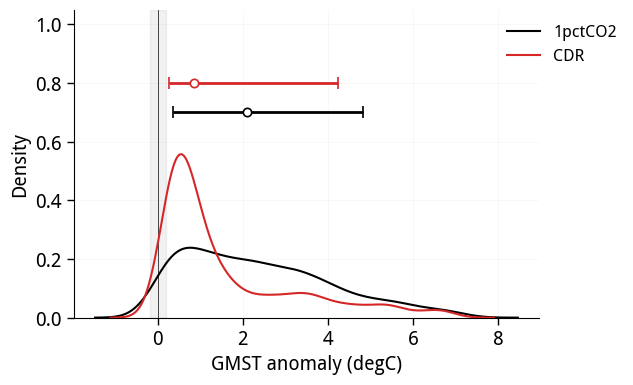

In [27]:
plt.figure(figsize=(6,4))
plt.axvspan(gmst_pic.quantile(0.1, dim=(('time', 'model'))), gmst_pic.quantile(0.9, dim=(('time', 'model'))), color='tab:gray', alpha=0.1)
plt.axvline(gmst_pic.quantile(0.5, dim=(('time', 'model'))), color='k', lw=0.5)

sns.kdeplot(gmst_trans.to_numpy().flatten(), color='k', label='1pctCO2')
plot_dist_inset(plt.gca(), gmst_trans, 0.7, 'k', dim=(("time", "model")))
# plt.axvline(trans_change.quantile(0.5, dim=(('time', 'model'))), color='k', lw=1.0)

sns.kdeplot(gmst_cdr.to_numpy().flatten(), color='tab:red', label='CDR')
plot_dist_inset(plt.gca(), gmst_cdr, 0.8, 'tab:red', dim=(("time", "model")))
# plt.axvline(cdr_change.quantile(0.5, dim=(('time', 'model'))), color='tab:red', lw=1.0)

# plt.xlim(-50, 72)
plt.ylim(0, 1.05)
plt.xlabel('GMST anomaly (degC)')
plt.legend(frameon=False, fontsize=12, loc='upper right', bbox_to_anchor=(1.2,1.0))
plot_decorator()


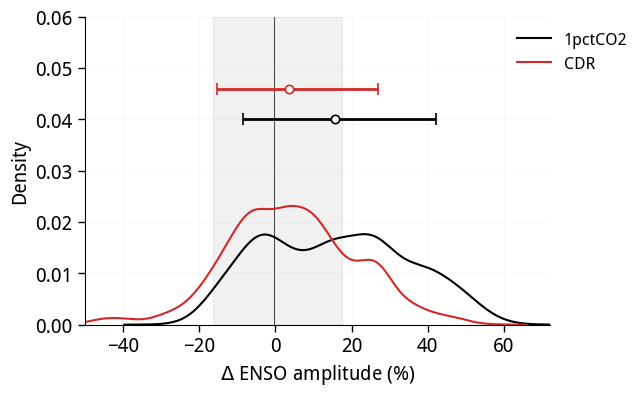

In [28]:
plt.figure(figsize=(6,4))
plt.axvspan(pic_change.quantile(0.1, dim=(('time', 'model'))), pic_change.quantile(0.9, dim=(('time', 'model'))), color='tab:gray', alpha=0.1)
plt.axvline(pic_change.quantile(0.5, dim=(('time', 'model'))), color='k', lw=0.5)

sns.kdeplot(trans_change.to_numpy().flatten(), color='k', label='1pctCO2')
plot_dist_inset(plt.gca(), trans_change, 0.04, 'k', dim=(("time", "model")))
# plt.axvline(trans_change.quantile(0.5, dim=(('time', 'model'))), color='k', lw=1.0)

sns.kdeplot(cdr_change.to_numpy().flatten(), color='tab:red', label='CDR')
plot_dist_inset(plt.gca(), cdr_change, 0.046, 'tab:red', dim=(("time", "model")))
# plt.axvline(cdr_change.quantile(0.5, dim=(('time', 'model'))), color='tab:red', lw=1.0)


plt.xlim(-50, 72)
plt.ylim(0, 0.06)
plt.legend(frameon=False, fontsize=12, loc='upper right', bbox_to_anchor=(1.2,1.0))
plt.xlabel('$\Delta$ ENSO amplitude (%)')
plot_decorator()


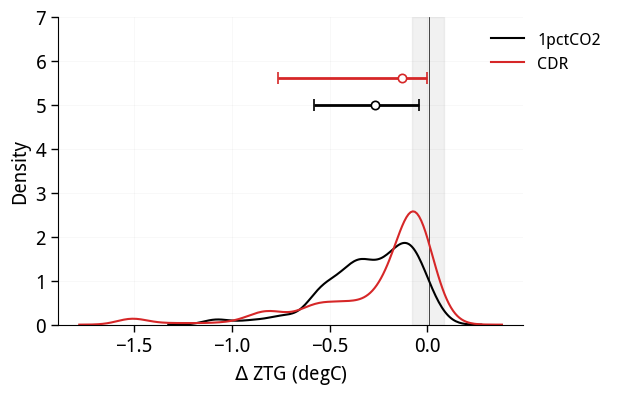

In [29]:
plt.figure(figsize=(6,4))
plt.axvspan(sst_grad_pic.quantile(0.1, dim=(('time', 'model'))), sst_grad_pic.quantile(0.9, dim=(('time', 'model'))), color='tab:gray', alpha=0.1)
plt.axvline(sst_grad_pic.quantile(0.5, dim=(('time', 'model'))), color='k', lw=0.5)

sns.kdeplot(sst_grad_trans.to_numpy().flatten(), color='k', label='1pctCO2')
plot_dist_inset(plt.gca(), sst_grad_trans, 5, 'k', dim=(("time", "model")))
# plt.axvline(trans_change.quantile(0.5, dim=(('time', 'model'))), color='k', lw=1.0)

sns.kdeplot(sst_grad_cdr.to_numpy().flatten(), color='tab:red', label='CDR')
plot_dist_inset(plt.gca(), sst_grad_cdr, 5.6, 'tab:red', dim=(("time", "model")))
# plt.axvline(cdr_change.quantile(0.5, dim=(('time', 'model'))), color='tab:red', lw=1.0)

# plt.xlim(-50, 72)
plt.ylim(0, 7)
plt.xlabel('$\Delta$ ZTG (degC)')
plt.legend(frameon=False, fontsize=12, loc='upper right', bbox_to_anchor=(1.2,1.0))
plot_decorator()


In [41]:
def calculate_1pctco2_concentration(picontrol_co2, years, reverse=False):
    """
    Calculates the CO2 concentration for a 1pctCO2 simulation.

    Args:
        picontrol_co2 (float): The CO2 concentration in the picontrol experiment (ppm).
        years (int): The number of years the simulation runs for.

    Returns:
        np.ndarray: Array of CO2 concentrations for each year, starting from year 0.
    """
    # Year 0 to years inclusive
    year_array = np.arange(years + 1)
    if reverse:
        co2_concentrations = picontrol_co2 * (0.99 ** year_array)
    else:
        co2_concentrations = picontrol_co2 * (1.01 ** year_array)
    return co2_concentrations

# # Example usage
# picontrol_value = 284.7  # preindustrial concentration in ppm
# simulation_years = 140   # length of simulation

# co2_levels = calculate_1pctco2_concentration(picontrol_value, simulation_years)

# # Show first 10 years and last few
# print("First 10 years:", co2_levels[:10])
# print("Year 70 (doubling):", co2_levels[70])
# print("Year 140 (quadrupling):", co2_levels[140])

In [274]:
len_1pct = len(gmst_trans.mean('model').isel(time = slice(0, -1)).dropna('time'))
len_cdr = len(gmst_cdr.mean('model').isel(time = slice(0, 140)).dropna('time'))

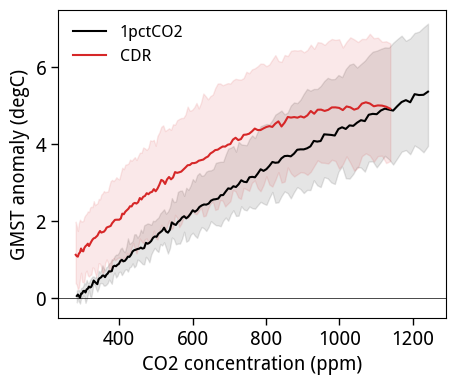

In [275]:
plt.figure(figsize=(5,4))
plt.plot(calculate_1pctco2_concentration(284.7, len_1pct-1), gmst_trans.mean('model').isel(time = slice(0, -1)).dropna('time'), color='k', label='1pctCO2')
plt.fill_between(calculate_1pctco2_concentration(284.7, len_1pct-1), gmst_trans.quantile(0.1, 'model').isel(time = slice(0, -1)).dropna('time'), gmst_trans.quantile(0.9, 'model').isel(time = slice(0, -1)).dropna('time'), color='k', alpha=0.1)
plt.plot(calculate_1pctco2_concentration(284.7*4, len_cdr-1, reverse=True), gmst_cdr.mean('model').isel(time = slice(0, 140)).dropna('time'), color='tab:red', label='CDR')
plt.fill_between(calculate_1pctco2_concentration(284.7*4, len_cdr-1, reverse=True), gmst_cdr.quantile(0.1, 'model').isel(time = slice(0, 140)).dropna('time'), gmst_cdr.quantile(0.9, 'model').isel(time = slice(0, 140)).dropna('time'), color='tab:red', alpha=0.1)
# plt.axvline(284.7, color='k', lw=0.5)
plt.axhline(0, color='k', lw=0.5)

plt.ylabel('GMST anomaly (degC)')
plt.xlabel('CO2 concentration (ppm)')
plt.legend(frameon=False, fontsize=12, loc='upper left', ncol=1)
# plot_decorator()

# plt.minorticks_on()
# # plt.ylim(0.5,3.5)
# # sns.despine()

In [43]:
len_1pct = len(sst_grad_trans.mean('model').isel(time = slice(0, -1)).dropna('time'))
len_cdr = len(sst_grad_cdr.mean('model').isel(time = slice(0, 140)).dropna('time'))

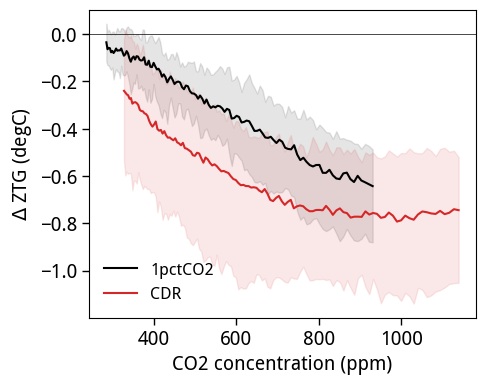

In [44]:
plt.figure(figsize=(5,4))
plt.plot(calculate_1pctco2_concentration(284.7, len_1pct-1), sst_grad_trans.mean('model').isel(time = slice(0, -1)).dropna('time'), color='k', label='1pctCO2')
plt.fill_between(calculate_1pctco2_concentration(284.7, len_1pct-1), sst_grad_trans.quantile(0.1, 'model').isel(time = slice(0, -1)).dropna('time'), sst_grad_trans.quantile(0.9, 'model').isel(time = slice(0, -1)).dropna('time'), color='k', alpha=0.1)
plt.plot(calculate_1pctco2_concentration(284.7*4, len_cdr-1, reverse=True), sst_grad_cdr.mean('model').isel(time = slice(0, 140)).dropna('time'), color='tab:red', label='CDR')
plt.fill_between(calculate_1pctco2_concentration(284.7*4, len_cdr-1, reverse=True), sst_grad_cdr.quantile(0.1, 'model').isel(time = slice(0, 140)).dropna('time'), sst_grad_cdr.quantile(0.9, 'model').isel(time = slice(0, 140)).dropna('time'), color='tab:red', alpha=0.1)
# plt.axvline(284.7, color='k', lw=0.5)
plt.axhline(0, color='k', lw=0.5)

plt.ylabel('$\Delta$ ZTG (degC)')
plt.xlabel('CO2 concentration (ppm)')
plt.legend(frameon=False, fontsize=12, loc='lower left', ncol=1)
# plot_decorator()

# plt.minorticks_on()
# # plt.ylim(0.5,3.5)
# # sns.despine()

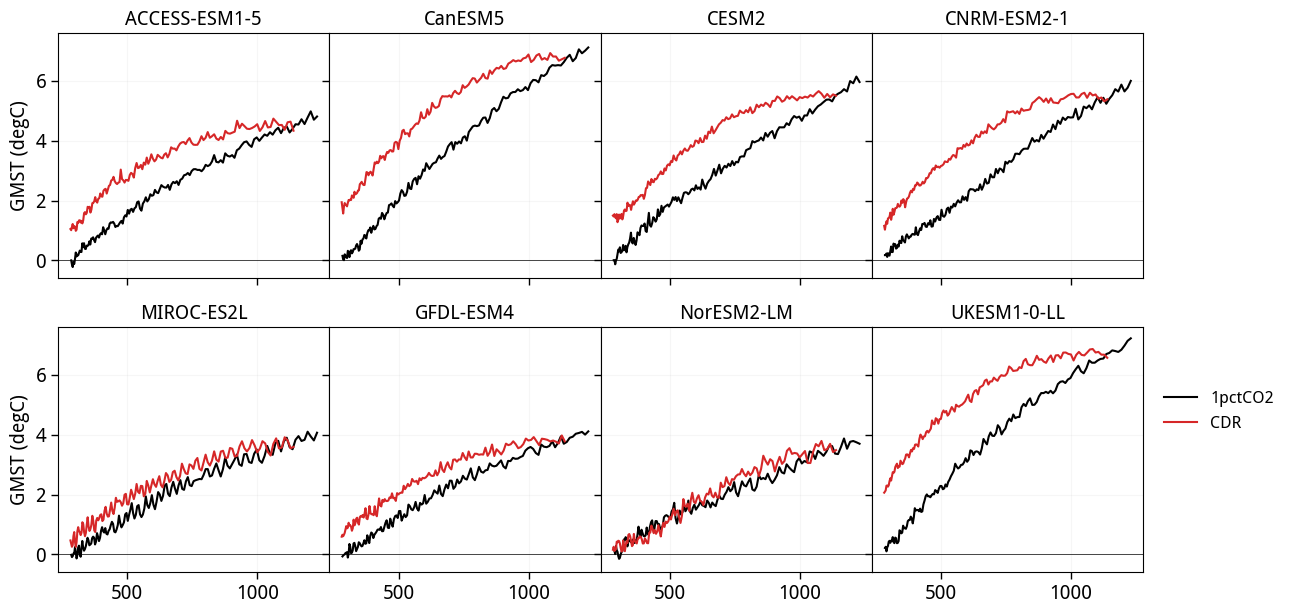

In [42]:
fig, axarr = plt.subplots(nrows=2, ncols=4, figsize=(14,7), constrained_layout=True, sharex=True, sharey=True)
axlist = axarr.flatten()
for i in range(len(axlist)):
    len_1pct = len(gmst_trans.isel(model = i).isel(time = slice(1, -1)).dropna('time'))
    len_cdr = len(gmst_cdr.isel(model = i).isel(time = slice(0, 140)).dropna('time'))
    axlist[i].plot(calculate_1pctco2_concentration(284.7, len_1pct-1), gmst_trans.isel(model=i).isel(time = slice(1, -1)).dropna('time'), color='k', label='1pctCO2')
    axlist[i].plot(calculate_1pctco2_concentration(284.7*4, len_cdr-1, reverse=True), gmst_cdr.isel(model=i).isel(time = slice(0, 140)).dropna('time'), color='tab:red', label='CDR')
    #
    #
    # axlist[i].set_xticks(np.arange(50, 450, 100))
    # axlist[i].set_yticklabels([])
    axlist[i].axhline(0.0, color='k', ls='-', lw=0.5)
    axlist[i].grid(alpha=0.1)
    # axlist[i].set_title(models_cdr[i] + f' (n = {len(trans_dat[models_cdr[i]].model)})', fontsize=14)
    axlist[i].set_title(models_cdr[i], fontsize=14)

axlist[0].set_ylabel('GMST (degC)')
axlist[4].set_ylabel('GMST (degC)')
axlist[-1].legend(frameon=False, fontsize=12, bbox_to_anchor=(1.02, 0.8))

plt.subplots_adjust(wspace=0.0, hspace=0.2)
# plt.minorticks_on()
# plt.ylim(0.5,3.5)
# sns.despine()

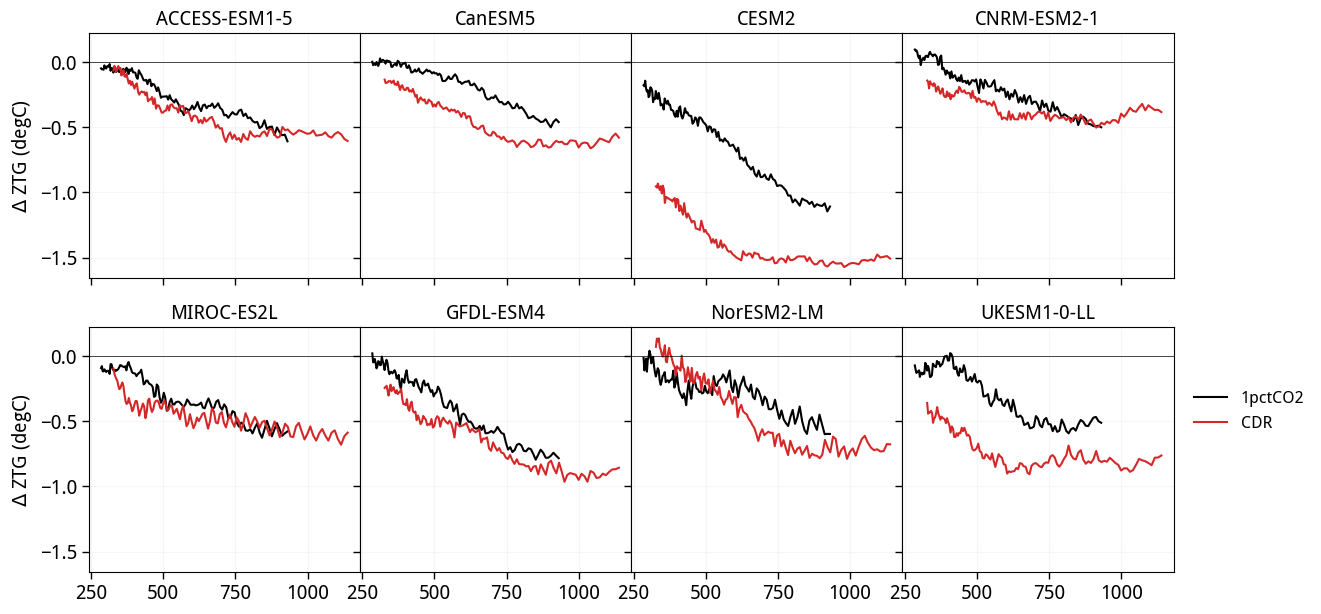

In [40]:
fig, axarr = plt.subplots(nrows=2, ncols=4, figsize=(14,7), constrained_layout=True, sharex=True, sharey=True)
axlist = axarr.flatten()
for i in range(len(axlist)):
    len_1pct = len(sst_grad_trans.isel(model = i).isel(time = slice(1, -1)).dropna('time'))
    len_cdr = len(sst_grad_cdr.isel(model = i).isel(time = slice(0, 140)).dropna('time'))
    axlist[i].plot(calculate_1pctco2_concentration(284.7, len_1pct-1), sst_grad_trans.isel(model=i).isel(time = slice(1, -1)).dropna('time'), color='k', label='1pctCO2')
    axlist[i].plot(calculate_1pctco2_concentration(284.7*4, len_cdr-1, reverse=True), sst_grad_cdr.isel(model=i).isel(time = slice(0, 140)).dropna('time'), color='tab:red', label='CDR')
    #
    #
    # axlist[i].set_xticks(np.arange(50, 450, 100))
    # axlist[i].set_yticklabels([])
    axlist[i].axhline(0.0, color='k', ls='-', lw=0.5)
    axlist[i].grid(alpha=0.1)
    # axlist[i].set_title(models_cdr[i] + f' (n = {len(trans_dat[models_cdr[i]].model)})', fontsize=14)
    axlist[i].set_title(models_cdr[i], fontsize=14)

axlist[0].set_ylabel('$\Delta$ ZTG (degC)')
axlist[4].set_ylabel('$\Delta$ ZTG (degC)')
axlist[-1].legend(frameon=False, fontsize=12, bbox_to_anchor=(1.02, 0.8))

plt.subplots_adjust(wspace=0.0, hspace=0.2)
# plt.minorticks_on()
# plt.ylim(0.5,3.5)
# sns.despine()

### ENSO periodicity

In [32]:
from functions import periodicity_funcs

In [34]:
arr = []
for i in range(len(pic_dat)):
    nino34 = funcs.detrend_rolling_window(pic_dat[models_zec[i]].sel(lat = slice(-5, 5), lon = slice(-170+360, -120+360)).weighted(weights).mean(('lat', 'lon')), window_size=15).isel(time = slice(1, -1), model=0).drop('model')
    try:
        nino34['time'] = xr.cftime_range('0100-01-01', f'0{len(nino34.time.dt.year) + 99}-01-01', freq='YS')
    except ValueError:
        nino34['time'] = xr.cftime_range('0100-01-01', f'{len(nino34.time.dt.year) + 99}-01-01', freq='YS')
    arr.append(nino34)
    print(f'done {i}', end='\r')

nino34_pic = xr.concat(arr, dim=models_zec, coords='minimal', compat='override').rename(concat_dim = 'model')

In [35]:
arr = []
for i in range(len(trans_dat)):
    nino34 = funcs.detrend_rolling_window(trans_dat[models_zec[i]].sel(lat = slice(-5, 5), lon = slice(-170+360, -120+360)).weighted(weights).mean(('lat', 'lon')), window_size=15).isel(time = slice(1, -1), model=0).drop('model')
    try:
        nino34['time'] = xr.cftime_range('0100-01-01', f'0{len(nino34.time.dt.year) + 99}-01-01', freq='YS')
    except ValueError:
        nino34['time'] = xr.cftime_range('0100-01-01', f'{len(nino34.time.dt.year) + 99}-01-01', freq='YS')
    arr.append(nino34)
    print(f'done {i}', end='\r')

nino34_trans = xr.concat(arr, dim=models_zec, coords='minimal', compat='override').rename(concat_dim = 'model')

In [36]:
arr = []
for i in range(len(stable1000_dat)):
    nino34 = funcs.detrend_rolling_window(stable1000_dat[models_zec[i]].sel(lat = slice(-5, 5), lon = slice(-170+360, -120+360)).weighted(weights).mean(('lat', 'lon')), window_size=15).isel(time = slice(1, -1), model=0).drop('model')
    try:
        nino34['time'] = xr.cftime_range('0100-01-01', f'0{len(nino34.time.dt.year) + 99}-01-01', freq='YS')
    except ValueError:
        nino34['time'] = xr.cftime_range('0100-01-01', f'{len(nino34.time.dt.year) + 99}-01-01', freq='YS')
    arr.append(nino34)
    print(f'done {i}', end='\r')

nino34_stable = xr.concat(arr, dim=models_zec, coords='minimal', compat='override').rename(concat_dim = 'model')

In [37]:
nino34_stable

<xarray.DataArray 'tas' (model: 9, time: 329)>
array([[-1.29454342, -0.09292933,  1.3183331 , ...,         nan,
                nan,         nan],
       [-0.80898136, -0.46718214, -0.34021253, ...,         nan,
                nan,         nan],
       [ 0.50867019,  1.31899573, -1.54217955, ...,         nan,
                nan,         nan],
       ...,
       [-0.10402168,  0.74607466,  0.07702501, ...,         nan,
                nan,         nan],
       [-1.87032622, -2.40632613,  0.17197993, ...,         nan,
                nan,         nan],
       [ 0.56396972, -0.74855399, -0.09584024, ..., -0.33080311,
         1.00959449, -0.08837915]])
Coordinates:
  * time                (time) object 0100-01-01 00:00:00 ... 0428-01-01 00:0...
    height              (time) float64 2.0 2.0 2.0 2.0 2.0 ... nan nan nan nan
    latitude_longitude  (time) float64 nan nan nan nan nan ... nan nan nan nan
    month               (time) float64 6.0 6.0 6.0 6.0 6.0 ... nan nan nan nan
  * model               (model) object 'ACCESS-ESM1-5' ... 'UKESM1-0-LL'

In [38]:
psd_ensemble_pic, psd_ar1_ensemble_pic, psd_wn_ensemble_pic, morlet_ensemble_pic, coi_ensemble_pic, common_periods, common_scales, max_time =  periodicity_funcs.generate_spectrum_ensemble(nino34_pic)

In [39]:

# PSD ensemble mean and spread
psd_mean_pic = np.mean(psd_ensemble_pic, axis=0)
psd_std_pic = np.std(psd_ensemble_pic, axis=0)

# Morlet ensemble mean (ignoring varying lengths for now)
morlet_mean_pic = np.mean(morlet_ensemble_pic, axis=0)
morlet_std_pic = np.std(morlet_ensemble_pic, axis=0)

# Average COI across ensemble (make sure you collected this earlier!)
coi_mean_pic = np.mean(np.vstack(coi_ensemble_pic), axis=0)

In [40]:
import matplotlib.ticker as ticker

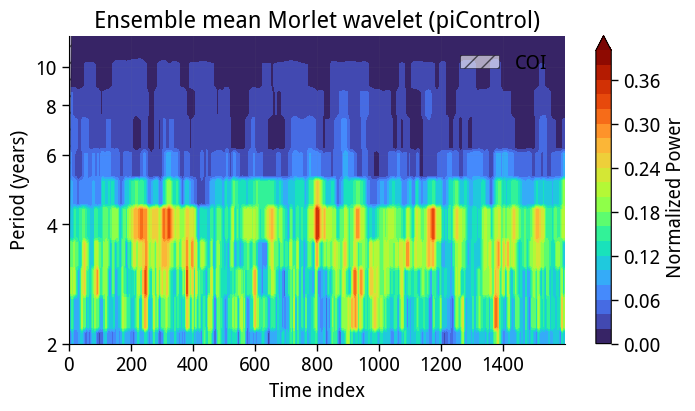

In [41]:
cutoff_shape = 1600
T, S = np.meshgrid(np.arange(morlet_mean_pic[:, :cutoff_shape].shape[1]), common_scales)

plt.figure(figsize=(8,4))
c = plt.contourf(T, S, morlet_mean_pic[:, :cutoff_shape], 100, cmap='turbo', vmin=0, vmax=0.40, levels= np.arange(0, 0.42, 0.02), extend='max')
plt.colorbar(c, label='Normalized Power')

# Log y-axis for scales/periods
plt.yscale('log')

# Add COI shading (cone below curve)
plt.fill_between(np.arange(cutoff_shape), coi_mean_pic[:cutoff_shape],
                 S.max(), color='white', alpha=0.6, hatch='//',
                 edgecolor='k', linewidth=0.5, label='COI')

plt.xlabel('Time index')
plt.ylabel('Period (years)')
plt.title('Ensemble mean Morlet wavelet (piControl)')
plt.ylim(2, 12)
plt.legend(frameon=False)

ax = plt.gca()
# Use base=10, ticks at integer multiples
ax.yaxis.set_major_locator(ticker.LogLocator(base=10.0, subs=np.arange(0.0, 12.0, 2) * 0.1, numticks=10))
ax.yaxis.set_minor_locator(ticker.LogLocator(base=10.0, subs=np.arange(0.0, 12.0, 2), numticks=10))

# Use plain numbers instead of 10^x
ax.yaxis.set_major_formatter(ticker.ScalarFormatter())
ax.yaxis.set_minor_formatter(ticker.NullFormatter())

plot_decorator()

In [42]:
psd_ensemble_trans, psd_ar1_ensemble_trans, psd_wn_ensemble_trans, morlet_ensemble_trans, coi_ensemble_trans, common_periods, common_scales, max_time =  periodicity_funcs.generate_spectrum_ensemble(nino34_trans)

In [43]:
# PSD ensemble mean and spread
psd_mean_trans = np.mean(psd_ensemble_trans, axis=0)
psd_std_trans = np.std(psd_ensemble_trans, axis=0)

# Morlet ensemble mean (ignoring varying lengths for now)
morlet_mean_trans = np.mean(morlet_ensemble_trans, axis=0)
morlet_std_trans = np.std(morlet_ensemble_trans, axis=0)

# Average COI across ensemble (make sure you collected this earlier!)
coi_mean_trans = np.mean(np.vstack(coi_ensemble_trans), axis=0)

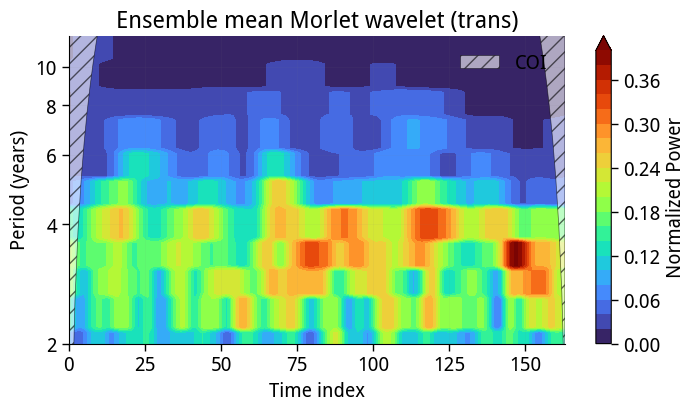

In [44]:
cutoff_shape = 164
T, S = np.meshgrid(np.arange(morlet_mean_trans[:, :cutoff_shape].shape[1]), common_scales)

plt.figure(figsize=(8,4))
c = plt.contourf(T, S, morlet_mean_trans[:, :cutoff_shape], 100, cmap='turbo', vmin=0, vmax=0.40, levels= np.arange(0, 0.42, 0.02), extend='max')
plt.colorbar(c, label='Normalized Power')

# Log y-axis for scales/periods
plt.yscale('log')

# Add COI shading (cone below curve)
plt.fill_between(np.arange(cutoff_shape), coi_mean_trans[:cutoff_shape],
                 S.max(), color='white', alpha=0.6, hatch='//',
                 edgecolor='k', linewidth=0.5, label='COI')

plt.xlabel('Time index')
plt.ylabel('Period (years)')
plt.title('Ensemble mean Morlet wavelet (trans)')
plt.ylim(2, 12)
plt.legend(frameon=False)

ax = plt.gca()
# Use base=10, ticks at integer multiples
ax.yaxis.set_major_locator(ticker.LogLocator(base=10.0, subs=np.arange(0.0, 12.0, 2) * 0.1, numticks=10))
ax.yaxis.set_minor_locator(ticker.LogLocator(base=10.0, subs=np.arange(0.0, 12.0, 2), numticks=10))

# Use plain numbers instead of 10^x
ax.yaxis.set_major_formatter(ticker.ScalarFormatter())
ax.yaxis.set_minor_formatter(ticker.NullFormatter())

plot_decorator()

In [45]:
psd_ensemble_stable, psd_ar1_ensemble_stable, psd_wn_ensemble_stable, morlet_ensemble_stable, coi_ensemble_stable, common_periods, common_scales, max_time =  periodicity_funcs.generate_spectrum_ensemble(nino34_stable)

In [46]:
# PSD ensemble mean and spread
psd_mean_stable = np.mean(psd_ensemble_stable, axis=0)
psd_std_stable = np.std(psd_ensemble_stable, axis=0)

# Morlet ensemble mean (ignoring varying lengths for now)
morlet_mean_stable = np.mean(morlet_ensemble_stable, axis=0)
morlet_std_stable = np.std(morlet_ensemble_stable, axis=0)

# Average COI across ensemble (make sure you collected this earlier!)
coi_mean_stable = np.mean(np.vstack(coi_ensemble_stable), axis=0)

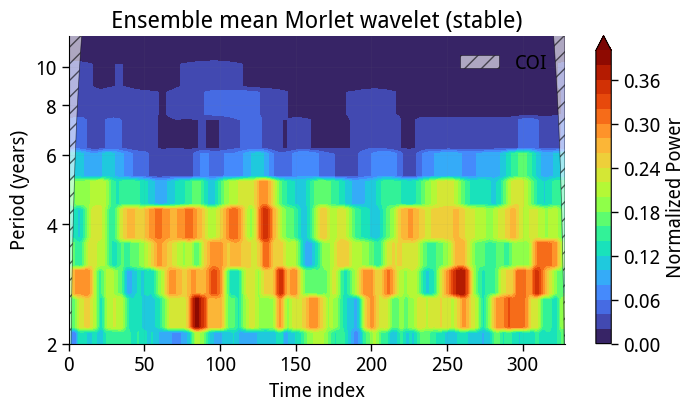

In [47]:
cutoff_shape = 329
T, S = np.meshgrid(np.arange(morlet_mean_stable[:, :cutoff_shape].shape[1]), common_scales)

plt.figure(figsize=(8,4))
c = plt.contourf(T, S, morlet_mean_stable[:, :cutoff_shape], 100, cmap='turbo', vmin=0, vmax=0.40, levels= np.arange(0, 0.42, 0.02), extend='max')
plt.colorbar(c, label='Normalized Power')

# Log y-axis for scales/periods
plt.yscale('log')

# Add COI shading (cone below curve)
plt.fill_between(np.arange(cutoff_shape), coi_mean_stable[:cutoff_shape],
                 S.max(), color='white', alpha=0.6, hatch='//',
                 edgecolor='k', linewidth=0.5, label='COI')

plt.xlabel('Time index')
plt.ylabel('Period (years)')
plt.title('Ensemble mean Morlet wavelet (stable)')
plt.ylim(2, 12)
plt.legend(frameon=False)

ax = plt.gca()
# Use base=10, ticks at integer multiples
ax.yaxis.set_major_locator(ticker.LogLocator(base=10.0, subs=np.arange(0.0, 12.0, 2) * 0.1, numticks=10))
ax.yaxis.set_minor_locator(ticker.LogLocator(base=10.0, subs=np.arange(0.0, 12.0, 2), numticks=10))

# Use plain numbers instead of 10^x
ax.yaxis.set_major_formatter(ticker.ScalarFormatter())
ax.yaxis.set_minor_formatter(ticker.NullFormatter())

plot_decorator()

In [48]:
morlet_anomaly_trans = morlet_mean_trans - np.mean(morlet_mean_pic[:, :1600], axis=1).reshape(100, 1).repeat(164, 1)

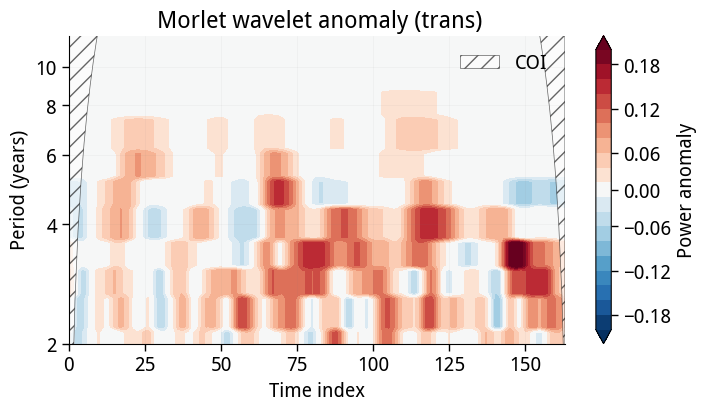

In [49]:
cutoff_shape = 164
T, S = np.meshgrid(np.arange(morlet_anomaly_trans[:, :cutoff_shape].shape[1]), common_scales)

plt.figure(figsize=(8,4))
c = plt.contourf(T, S, morlet_anomaly_trans[:, :cutoff_shape], 100, cmap='RdBu_r', vmin=-0.2, vmax=0.2, levels= np.concatenate((np.arange(-0.2, 0, 0.02), np.arange(0.02, 0.22, 0.02))), extend='both')
plt.colorbar(c, label='Power anomaly', ticks = np.arange(-0.18, 0.24, 0.06))

# Log y-axis for scales/periods
plt.yscale('log')

# Add COI shading (cone below curve)
plt.fill_between(np.arange(cutoff_shape), coi_mean_trans[:cutoff_shape],
                 S.max(), color='white', alpha=0.6, hatch='//',
                 edgecolor='k', linewidth=0.5, label='COI')

plt.xlabel('Time index')
plt.ylabel('Period (years)')
plt.title(' Morlet wavelet anomaly (trans)')
plt.ylim(2, 12)
plt.legend(frameon=False)

ax = plt.gca()
# Use base=10, ticks at integer multiples
ax.yaxis.set_major_locator(ticker.LogLocator(base=10.0, subs=np.arange(0.0, 12.0, 2) * 0.1, numticks=10))
ax.yaxis.set_minor_locator(ticker.LogLocator(base=10.0, subs=np.arange(0.0, 12.0, 2), numticks=10))

# Use plain numbers instead of 10^x
ax.yaxis.set_major_formatter(ticker.ScalarFormatter())
ax.yaxis.set_minor_formatter(ticker.NullFormatter())

plot_decorator()

In [50]:
morlet_anomaly_stable = morlet_mean_stable - np.mean(morlet_mean_pic[:, :1600], axis=1).reshape(100, 1).repeat(329, 1)

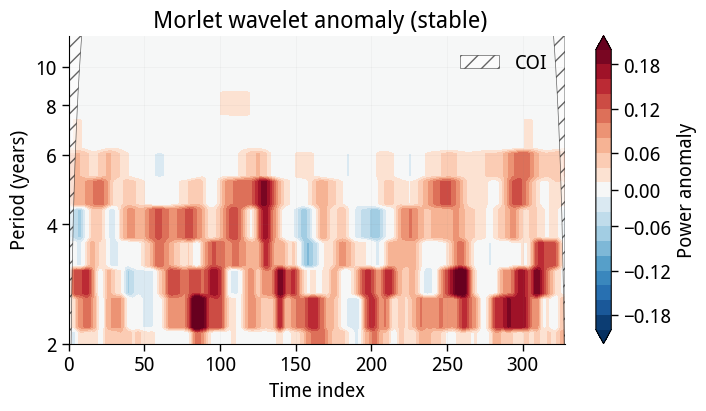

In [51]:
cutoff_shape = 329
T, S = np.meshgrid(np.arange(morlet_anomaly_stable[:, :cutoff_shape].shape[1]), common_scales)

plt.figure(figsize=(8,4))
c = plt.contourf(T, S, morlet_anomaly_stable[:, :cutoff_shape], 100, cmap='RdBu_r', vmin=-0.2, vmax=0.2, levels= np.concatenate((np.arange(-0.2, 0, 0.02), np.arange(0.02, 0.22, 0.02))), extend='both')
plt.colorbar(c, label='Power anomaly', ticks = np.arange(-0.18, 0.24, 0.06))

# Log y-axis for scales/periods
plt.yscale('log')

# Add COI shading (cone below curve)
plt.fill_between(np.arange(cutoff_shape), coi_mean_stable[:cutoff_shape],
                 S.max(), color='white', alpha=0.6, hatch='//',
                 edgecolor='k', linewidth=0.5, label='COI')

plt.xlabel('Time index')
plt.ylabel('Period (years)')
plt.title(' Morlet wavelet anomaly (stable)')
plt.ylim(2, 12)
plt.legend(frameon=False)

ax = plt.gca()
# Use base=10, ticks at integer multiples
ax.yaxis.set_major_locator(ticker.LogLocator(base=10.0, subs=np.arange(0.0, 12.0, 2) * 0.1, numticks=10))
ax.yaxis.set_minor_locator(ticker.LogLocator(base=10.0, subs=np.arange(0.0, 12.0, 2), numticks=10))

# Use plain numbers instead of 10^x
ax.yaxis.set_major_formatter(ticker.ScalarFormatter())
ax.yaxis.set_minor_formatter(ticker.NullFormatter())

plot_decorator()

In [52]:
morlet_anomaly_stable1 = morlet_mean_stable - np.mean(morlet_mean_trans[:, :164], axis=1).reshape(100, 1).repeat(329, 1)

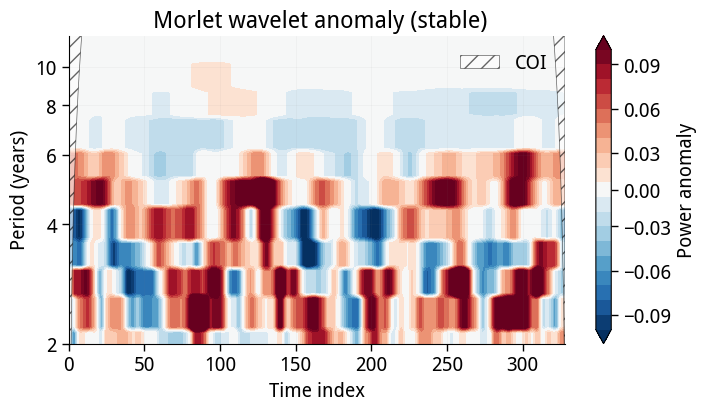

In [53]:
cutoff_shape = 329
T, S = np.meshgrid(np.arange(morlet_anomaly_stable1[:, :cutoff_shape].shape[1]), common_scales)

plt.figure(figsize=(8,4))
c = plt.contourf(T, S, morlet_anomaly_stable1[:, :cutoff_shape], 100, cmap='RdBu_r', vmin=-0.1, vmax=0.1, levels= np.concatenate((np.arange(-0.1, 0, 0.01), np.arange(0.01, 0.11, 0.01))), extend='both')
plt.colorbar(c, label='Power anomaly', ticks = np.arange(-0.09, 0.12, 0.03))

# Log y-axis for scales/periods
plt.yscale('log')

# Add COI shading (cone below curve)
plt.fill_between(np.arange(cutoff_shape), coi_mean_stable[:cutoff_shape],
                 S.max(), color='white', alpha=0.6, hatch='//',
                 edgecolor='k', linewidth=0.5, label='COI')

plt.xlabel('Time index')
plt.ylabel('Period (years)')
plt.title(' Morlet wavelet anomaly (stable)')
plt.ylim(2, 12)
plt.legend(frameon=False)

ax = plt.gca()
# Use base=10, ticks at integer multiples
ax.yaxis.set_major_locator(ticker.LogLocator(base=10.0, subs=np.arange(0.0, 12.0, 2) * 0.1, numticks=10))
ax.yaxis.set_minor_locator(ticker.LogLocator(base=10.0, subs=np.arange(0.0, 12.0, 2), numticks=10))

# Use plain numbers instead of 10^x
ax.yaxis.set_major_formatter(ticker.ScalarFormatter())
ax.yaxis.set_minor_formatter(ticker.NullFormatter())

plot_decorator()

### ZECMIP warming levels supplementary plots

In [103]:
# fig, axarr = plt.subplots(nrows=1, ncols=3, figsize=(14,4), constrained_layout=True, sharex=True, sharey=True)
# axlist = axarr.flatten()
# for i in range(len(axlist)):
#     xdata0 = pic_dat[models_zec_warming_levels[i]].time.dt.year
#     axlist[i].plot((xdata0 - xdata0[0])[1:350], pic_dat[models_zec_warming_levels[i]].weighted(weights).mean(('lat', 'lon')).isel(time = slice(1, 350), model=0), color='tab:gray', label='piControl')
#     #
#     xdata0 = trans_dat[models_zec_warming_levels[i]].time.dt.year
#     axlist[i].plot((xdata0 - xdata0[0])[1:-1], trans_dat[models_zec_warming_levels[i]].weighted(weights).mean(('lat', 'lon')).isel(time = slice(1, -1), model=0), color='k', label='1pcCO2')
#     #
#     xdata = stable750_dat[models_zec_warming_levels[i]].time.dt.year
#     axlist[i].plot((xdata - xdata0[0])[1:-1], np.squeeze(stable750_dat[models_zec_warming_levels[i]].weighted(weights).mean(('lat', 'lon')).isel(time = slice(1, -1)).to_numpy()), color='gold', ls='-', label='brch-750PgC')
#     #
#     xdata = stable1000_dat[models_zec_warming_levels[i]].time.dt.year
#     axlist[i].plot((xdata - xdata0[0])[1:-1], stable1000_dat[models_zec_warming_levels[i]].weighted(weights).mean(('lat', 'lon')).isel(time = slice(1, -1), model=0), color='tab:red', ls='-', label='CDR')
#     #
#     xdata = stable2000_dat[models_zec_warming_levels[i]].time.dt.year
#     axlist[i].plot((xdata - xdata0[0])[1:-1], np.squeeze(stable2000_dat[models_zec_warming_levels[i]].weighted(weights).mean(('lat', 'lon')).isel(time = slice(1, -1)).to_numpy()), color='maroon', ls='-', label='brch-750PgC')
#     #
#     axlist[i].set_xticks(np.arange(50, 450, 100))
#     # axlist[i].set_yticklabels([])
#     axlist[i].axhline(0.0, color='k', ls='-', lw=0.5)
#     axlist[i].grid(alpha=0.1)
#     # axlist[i].set_title(models_zec_warming_levels[i] + f' (n = {len(trans_dat[models_zec_warming_levels[i]].model)})', fontsize=14)
#     axlist[i].set_title(models_zec_warming_levels[i], fontsize=14)

# axlist[0].set_ylabel('Temperature anomaly (degC)')
# # axlist[4].set_ylabel('Temperature anomaly (degC)')
# axlist[0].legend(frameon=False, loc='upper right', fontsize=10)

# plt.subplots_adjust(wspace=0.0, hspace=0.2)
# plt.minorticks_on()
# # sns.despine()

In [104]:
zec_values_temporal = np.empty((len(models_zec_warming_levels), 350))
zec_values_temporal[:] = np.nan
for i in range(len(zec_values_temporal)):
    branching_time = int(stable750_dat[models_zec_warming_levels[i]].time[0].dt.year)
    if branching_time > 100 and branching_time < 1000:
        start_time = '0'+str(branching_time - 15)
        end_time = '0'+str(branching_time + 15)
    elif branching_time < 100:
        start_time = '00'+str(branching_time - 15)
        end_time = '00'+str(branching_time + 15)
    else:
        start_time = str(branching_time - 15)
        end_time = str(branching_time + 15)
    base = trans_dat[models_zec_warming_levels[i]].sel(time = slice(start_time, end_time)).weighted(weights).mean(('time', 'lat', 'lon')).isel(model=0)
    xdata0 = trans_dat[models_zec_warming_levels[i]].time.dt.year
    xdata = stable750_dat[models_zec_warming_levels[i]].time.dt.year
    zec_values_temporal[i, 0:len(xdata)-2] = stable750_dat[models_zec_warming_levels[i]].weighted(weights).mean(('lat', 'lon')).isel(time = slice(1, -1), model=0) - base
    # plt.plot((xdata - xdata0[i])[1:-1], zec_values_temporal, color='k', ls='-', label='1000PgC Branching', alpha=0.2)
    # # plt.set_xticks(np.arange(50, 450, 100))
    # # plt.set_yticklabels([])
    # # plt.axhline(0.0, color='k', ls='-', lw=0.5)
    # plt.grid(alpha=0.1)
    # # plt.set_title(models_zec_warming_levels[i] + f' (n = {len(trans_dat[models_zec_warming_levels[i]].model)})', fontsize=14)
    # plt.set_title(models_zec_warming_levels[i], fontsize=14)

# axlist[0].set_ylabel('Temperature anomaly (degC)')
# axlist[4].set_ylabel('Temperature anomaly (degC)')
# axlist[0].legend(frameon=False, loc='upper right', fontsize=10)

# plt.subplots_adjust(wspace=0.0, hspace=0.2)
# plt.minorticks_on()
# sns.despine()

Text(0.5, 1.0, 'brch-750PgC ZEC')

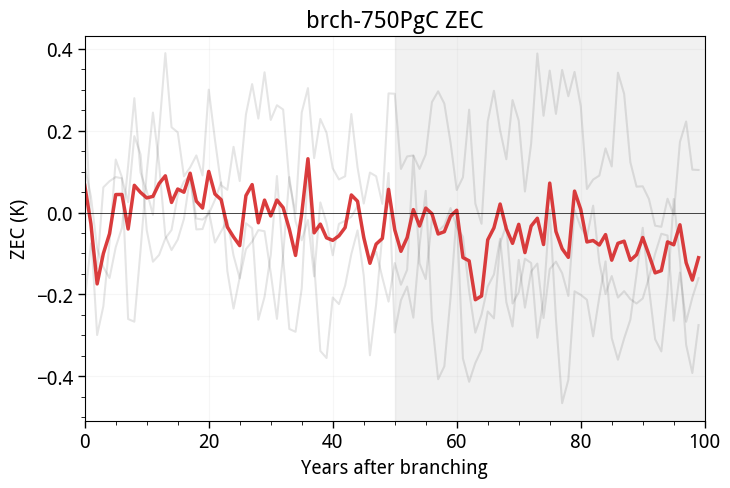

In [105]:
plt.figure(figsize=(8, 5))
for i in range(len(models_zec_warming_levels)):
    plt.plot(zec_values_temporal[i][:100], color='k', alpha=0.1)
plt.plot(np.nanmean(zec_values_temporal, axis=0)[:100], color='tab:red', alpha=0.9, lw=2.5)
# plt.set_yticklabels([])
plt.axhline(0.0, color='k', ls='-', lw=0.5)
plt.grid(alpha=0.1)
plt.minorticks_on()
plt.xlabel('Years after branching')
plt.ylabel('ZEC (K)')
plt.xlim(0, 100)
# plt.axvspan(10, 40, color='tab:blue', alpha=0.1)
# plt.axvspan(35, 65, color='tab:green', alpha=0.1)
# plt.axvspan(75, 105, color='tab:purple', alpha=0.1)
# plt.axvspan(105, 135, color='tab:red', alpha=0.1)
plt.axvspan(50, 100, color='tab:gray', alpha=0.1)
plt.title('brch-750PgC ZEC')

In [106]:
zec_values_temporal = np.empty((len(models_zec_warming_levels), 350))
zec_values_temporal[:] = np.nan
for i in range(len(zec_values_temporal)):
    branching_time = int(stable2000_dat[models_zec_warming_levels[i]].time[0].dt.year)
    if branching_time > 100 and branching_time < 1000:
        start_time = '0'+str(branching_time - 15)
        end_time = '0'+str(branching_time + 15)
    elif branching_time < 100:
        start_time = '00'+str(branching_time - 15)
        end_time = '00'+str(branching_time + 15)
    else:
        start_time = str(branching_time - 15)
        end_time = str(branching_time + 15)
    base = trans_dat[models_zec_warming_levels[i]].sel(time = slice(start_time, end_time)).weighted(weights).mean(('time', 'lat', 'lon')).isel(model=0)
    xdata0 = trans_dat[models_zec_warming_levels[i]].time.dt.year
    xdata = stable2000_dat[models_zec_warming_levels[i]].time.dt.year
    zec_values_temporal[i, 0:len(xdata)-2] = stable2000_dat[models_zec_warming_levels[i]].weighted(weights).mean(('lat', 'lon')).isel(time = slice(1, -1), model=0) - base
    # plt.plot((xdata - xdata0[i])[1:-1], zec_values_temporal, color='k', ls='-', label='1000PgC Branching', alpha=0.2)
    # # plt.set_xticks(np.arange(50, 450, 100))
    # # plt.set_yticklabels([])
    # # plt.axhline(0.0, color='k', ls='-', lw=0.5)
    # plt.grid(alpha=0.1)
    # # plt.set_title(models_zec_warming_levels[i] + f' (n = {len(trans_dat[models_zec_warming_levels[i]].model)})', fontsize=14)
    # plt.set_title(models_zec_warming_levels[i], fontsize=14)

# axlist[0].set_ylabel('Temperature anomaly (degC)')
# axlist[4].set_ylabel('Temperature anomaly (degC)')
# axlist[0].legend(frameon=False, loc='upper right', fontsize=10)

# plt.subplots_adjust(wspace=0.0, hspace=0.2)
# plt.minorticks_on()
# sns.despine()

Text(0.5, 1.0, 'brch-2000PgC ZEC')

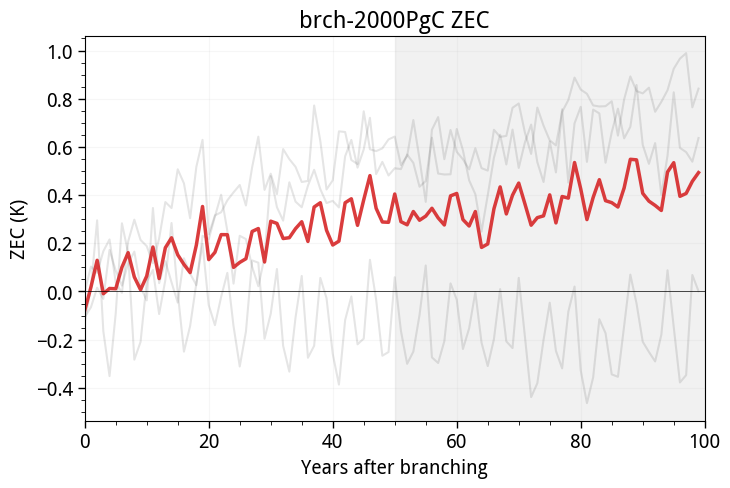

In [107]:
plt.figure(figsize=(8, 5))
for i in range(len(models_zec_warming_levels)):
    plt.plot(zec_values_temporal[i][:100], color='k', alpha=0.1)
plt.plot(np.nanmean(zec_values_temporal, axis=0)[:100], color='tab:red', alpha=0.9, lw=2.5)
# plt.set_yticklabels([])
plt.axhline(0.0, color='k', ls='-', lw=0.5)
plt.grid(alpha=0.1)
plt.minorticks_on()
plt.xlabel('Years after branching')
plt.ylabel('ZEC (K)')
plt.xlim(0, 100)
# plt.axvspan(10, 40, color='tab:blue', alpha=0.1)
# plt.axvspan(35, 65, color='tab:green', alpha=0.1)
# plt.axvspan(75, 105, color='tab:purple', alpha=0.1)
# plt.axvspan(105, 135, color='tab:red', alpha=0.1)
plt.axvspan(50, 100, color='tab:gray', alpha=0.1)
plt.title('brch-2000PgC ZEC')

In [108]:
# zec25_changes = []
# zec50_changes = []
# zec90_changes = []
# zec120_changes = []
zec_changes = []


for m in range(len(models_zec_warming_levels)):
    branching_time = int(stable750_dat[models_zec_warming_levels[m]].time[0].dt.year)
    if branching_time > 100 and branching_time < 1000:
        start_time = '0'+str(branching_time - 15)
        end_time = '0'+str(branching_time + 15)
    elif branching_time < 100:
        start_time = '00'+str(branching_time - 15)
        end_time = '00'+str(branching_time + 15)
    else:
        start_time = str(branching_time - 15)
        end_time = str(branching_time + 15)
    base = trans_dat[models_zec_warming_levels[m]].sel(time = slice(start_time, end_time)).mean(('time', 'model'))

    # post25 = stable750_dat[models_zec_warming_levels[m]].isel(time = slice(10, 40)).mean(('time', 'model'))
    # post50 = stable750_dat[models_zec_warming_levels[m]].isel(time = slice(35, 65)).mean(('time', 'model'))
    # post90 = stable750_dat[models_zec_warming_levels[m]].isel(time = slice(75, 105)).mean(('time', 'model'))
    # post120 = stable750_dat[models_zec_warming_levels[m]].isel(time = slice(105, 135)).mean(('time', 'model'))
    post = stable750_dat[models_zec_warming_levels[m]].isel(time = slice(50, 100)).mean(('time', 'model'))

    # zec25_changes.append((post25 - base))
    # zec50_changes.append((post50 - base))
    # zec90_changes.append((post90 - base))
    # zec120_changes.append((post120 - base))
    zec_changes.append((post - base))
    print(f'Completed {m+1}')

Completed 1
Completed 2
Completed 3


In [109]:
xx, yy = np.meshgrid(zec_changes[0].lon, zec_changes[0].lat)

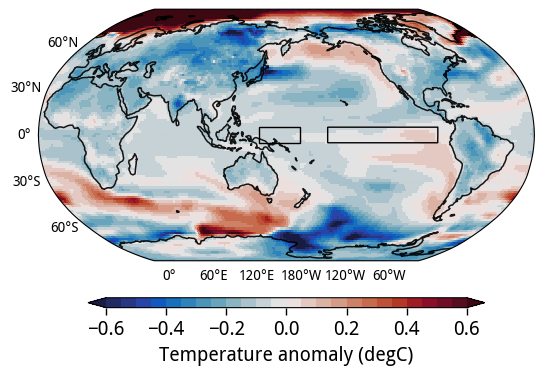

In [76]:
# plt.figure(figsize=(6,7))
ax = plt.axes(projection=ccrs.Robinson(central_longitude=160))
# ax.set_aspect('auto')
xr.concat(zec_changes, dim=models_zec_warming_levels).mean('concat_dim').plot.pcolormesh(transform=ccrs.PlateCarree(), cmap=cmocean.cm.balance, levels=np.arange(-0.6, 0.65, 0.05), cbar_kwargs=dict(orientation='horizontal', shrink=0.8, aspect=40, pad=0.1, label='Temperature anomaly (degC)', ticks=np.arange(-0.6, 0.8, 0.2)))
plot_background(ax)
ax.add_patch(mpatches.Rectangle(xy=[190, -5], width=80, height=10,
                            facecolor='none', edgecolor='k',
                            transform=ccrs.PlateCarree()))
ax.add_patch(mpatches.Rectangle(xy=[140, -5], width=30, height=10,
                            facecolor='none', edgecolor='k',
                            transform=ccrs.PlateCarree()))
# axlist[i].add_patch(mpatches.Rectangle(xy=[250, -30], width=40, height=20,
#                                 facecolor='none', edgecolor='k',
#                                 transform=ccrs.PlateCarree()))
# axlist[i].add_patch(mpatches.Rectangle(xy=[140, 60], width=150, height=20,
#                                             facecolor='none', edgecolor='tab:green', lw=1.5,
#                                             transform=ccrs.PlateCarree()))
# axlist[i].add_patch(mpatches.Rectangle(xy=[140, -80], width=150, height=20,
#                                             facecolor='none', edgecolor='tab:green', lw=1.5,
#                                             transform=ccrs.PlateCarree()))
# axlist[i].add_patch(mpatches.Rectangle(xy=[190, 20], width=60, height=20,
#                                             facecolor='none', edgecolor='k', lw=1.5,
#                                             transform=ccrs.PlateCarree()))
# axlist[i].add_patch(mpatches.Rectangle(xy=[210, -40], width=60, height=30,
#                                             facecolor='none', edgecolor='k', lw=1.5,
#                                             transform=ccrs.PlateCarree()))

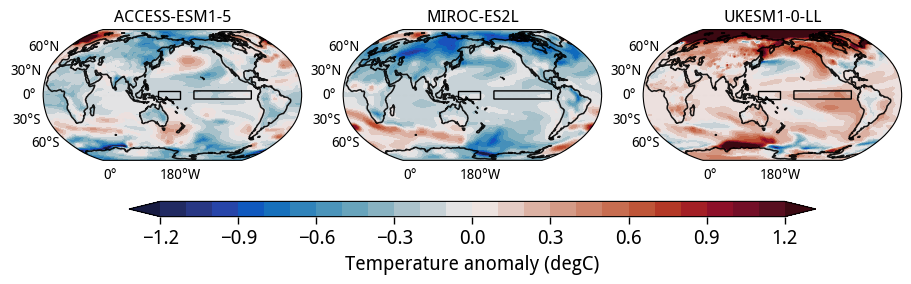

In [77]:
plot_maps(xx, yy, zec_changes, titles=models_zec_warming_levels, labels=['']*8, cmap=cmocean.cm.balance, levels=np.arange(-1.2, 1.3, 0.1), cbar_label = 'Temperature anomaly (degC)', nrows=1, ncols=3, figsize=(9,4.5), land_mask_list = [], add_patch=True, add_patch_extra=False, cbar_orientation='horizontal', hatch_type = 'insig', proj=ccrs.Robinson(central_longitude=160))

In [78]:
# zec25_changes = []
# zec50_changes = []
# zec90_changes = []
# zec120_changes = []
zec_changes = []


for m in range(len(models_zec_warming_levels)):
    branching_time = int(stable1000_dat[models_zec_warming_levels[m]].time[0].dt.year)
    if branching_time > 100 and branching_time < 1000:
        start_time = '0'+str(branching_time - 15)
        end_time = '0'+str(branching_time + 15)
    elif branching_time < 100:
        start_time = '00'+str(branching_time - 15)
        end_time = '00'+str(branching_time + 15)
    else:
        start_time = str(branching_time - 15)
        end_time = str(branching_time + 15)
    base = trans_dat[models_zec_warming_levels[m]].sel(time = slice(start_time, end_time)).mean(('time', 'model'))

    # post25 = stable1000_dat[models_zec_warming_levels[m]].isel(time = slice(10, 40)).mean(('time', 'model'))
    # post50 = stable1000_dat[models_zec_warming_levels[m]].isel(time = slice(35, 65)).mean(('time', 'model'))
    # post90 = stable1000_dat[models_zec_warming_levels[m]].isel(time = slice(75, 105)).mean(('time', 'model'))
    # post120 = stable1000_dat[models_zec_warming_levels[m]].isel(time = slice(105, 135)).mean(('time', 'model'))
    post = stable1000_dat[models_zec_warming_levels[m]].isel(time = slice(50, 100)).mean(('time', 'model'))

    # zec25_changes.append((post25 - base))
    # zec50_changes.append((post50 - base))
    # zec90_changes.append((post90 - base))
    # zec120_changes.append((post120 - base))
    zec_changes.append((post - base))
    print(f'Completed {m+1}')

Completed 1
Completed 2
Completed 3


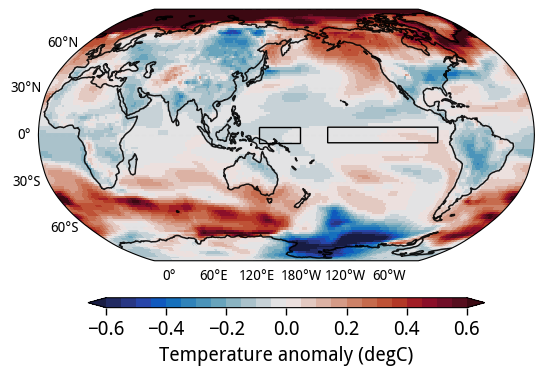

In [79]:
# plt.figure(figsize=(6,7))
ax = plt.axes(projection=ccrs.Robinson(central_longitude=160))
# ax.set_aspect('auto')
xr.concat(zec_changes, dim=models_zec_warming_levels).mean('concat_dim').plot.pcolormesh(transform=ccrs.PlateCarree(), cmap=cmocean.cm.balance, levels=np.arange(-0.6, 0.65, 0.05), cbar_kwargs=dict(orientation='horizontal', shrink=0.8, aspect=40, pad=0.1, label='Temperature anomaly (degC)', ticks=np.arange(-0.6, 0.8, 0.2)))
plot_background(ax)
ax.add_patch(mpatches.Rectangle(xy=[190, -5], width=80, height=10,
                            facecolor='none', edgecolor='k',
                            transform=ccrs.PlateCarree()))
ax.add_patch(mpatches.Rectangle(xy=[140, -5], width=30, height=10,
                            facecolor='none', edgecolor='k',
                            transform=ccrs.PlateCarree()))
# axlist[i].add_patch(mpatches.Rectangle(xy=[250, -30], width=40, height=20,
#                                 facecolor='none', edgecolor='k',
#                                 transform=ccrs.PlateCarree()))
# axlist[i].add_patch(mpatches.Rectangle(xy=[140, 60], width=150, height=20,
#                                             facecolor='none', edgecolor='tab:green', lw=1.5,
#                                             transform=ccrs.PlateCarree()))
# axlist[i].add_patch(mpatches.Rectangle(xy=[140, -80], width=150, height=20,
#                                             facecolor='none', edgecolor='tab:green', lw=1.5,
#                                             transform=ccrs.PlateCarree()))
# axlist[i].add_patch(mpatches.Rectangle(xy=[190, 20], width=60, height=20,
#                                             facecolor='none', edgecolor='k', lw=1.5,
#                                             transform=ccrs.PlateCarree()))
# axlist[i].add_patch(mpatches.Rectangle(xy=[210, -40], width=60, height=30,
#                                             facecolor='none', edgecolor='k', lw=1.5,
#                                             transform=ccrs.PlateCarree()))

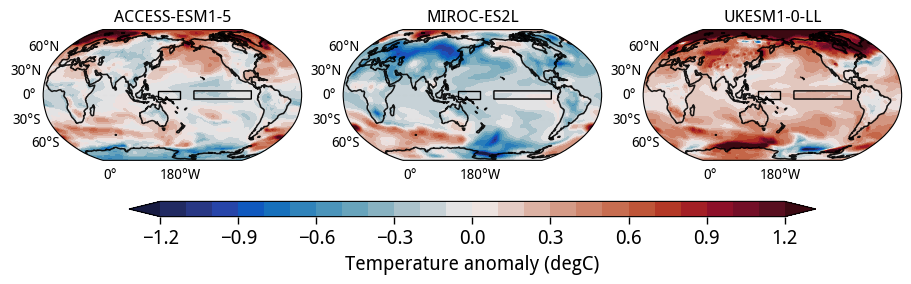

In [80]:
plot_maps(xx, yy, zec_changes, titles=models_zec_warming_levels, labels=['']*8, cmap=cmocean.cm.balance, levels=np.arange(-1.2, 1.3, 0.1), cbar_label = 'Temperature anomaly (degC)', nrows=1, ncols=3, figsize=(9,4.5), land_mask_list = [], add_patch=True, add_patch_extra=False, cbar_orientation='horizontal', hatch_type = 'insig', proj=ccrs.Robinson(central_longitude=160))

In [81]:
# zec25_changes = []
# zec50_changes = []
# zec90_changes = []
# zec120_changes = []
zec_changes = []


for m in range(len(models_zec_warming_levels)):
    branching_time = int(stable2000_dat[models_zec_warming_levels[m]].time[0].dt.year)
    if branching_time > 100 and branching_time < 1000:
        start_time = '0'+str(branching_time - 15)
        end_time = '0'+str(branching_time + 15)
    elif branching_time < 100:
        start_time = '00'+str(branching_time - 15)
        end_time = '00'+str(branching_time + 15)
    else:
        start_time = str(branching_time - 15)
        end_time = str(branching_time + 15)
    base = trans_dat[models_zec_warming_levels[m]].sel(time = slice(start_time, end_time)).mean(('time', 'model'))

    # post25 = stable2000_dat[models_zec_warming_levels[m]].isel(time = slice(10, 40)).mean(('time', 'model'))
    # post50 = stable2000_dat[models_zec_warming_levels[m]].isel(time = slice(35, 65)).mean(('time', 'model'))
    # post90 = stable2000_dat[models_zec_warming_levels[m]].isel(time = slice(75, 105)).mean(('time', 'model'))
    # post120 = stable2000_dat[models_zec_warming_levels[m]].isel(time = slice(105, 135)).mean(('time', 'model'))
    post = stable2000_dat[models_zec_warming_levels[m]].isel(time = slice(50, 100)).mean(('time', 'model'))

    # zec25_changes.append((post25 - base))
    # zec50_changes.append((post50 - base))
    # zec90_changes.append((post90 - base))
    # zec120_changes.append((post120 - base))
    zec_changes.append((post - base))
    print(f'Completed {m+1}')

Completed 1
Completed 2
Completed 3


In [82]:
xx, yy = np.meshgrid(zec_changes[0].lon, zec_changes[0].lat)

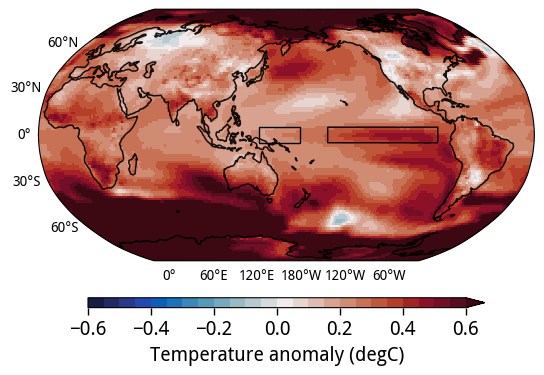

In [83]:
# plt.figure(figsize=(6,7))
ax = plt.axes(projection=ccrs.Robinson(central_longitude=160))
# ax.set_aspect('auto')
xr.concat(zec_changes, dim=models_zec_warming_levels).mean('concat_dim').plot.pcolormesh(transform=ccrs.PlateCarree(), cmap=cmocean.cm.balance, levels=np.arange(-0.6, 0.65, 0.05), cbar_kwargs=dict(orientation='horizontal', shrink=0.8, aspect=40, pad=0.1, label='Temperature anomaly (degC)', ticks=np.arange(-0.6, 0.8, 0.2)))
plot_background(ax)
ax.add_patch(mpatches.Rectangle(xy=[190, -5], width=80, height=10,
                            facecolor='none', edgecolor='k',
                            transform=ccrs.PlateCarree()))
ax.add_patch(mpatches.Rectangle(xy=[140, -5], width=30, height=10,
                            facecolor='none', edgecolor='k',
                            transform=ccrs.PlateCarree()))
# axlist[i].add_patch(mpatches.Rectangle(xy=[250, -30], width=40, height=20,
#                                 facecolor='none', edgecolor='k',
#                                 transform=ccrs.PlateCarree()))
# axlist[i].add_patch(mpatches.Rectangle(xy=[140, 60], width=150, height=20,
#                                             facecolor='none', edgecolor='tab:green', lw=1.5,
#                                             transform=ccrs.PlateCarree()))
# axlist[i].add_patch(mpatches.Rectangle(xy=[140, -80], width=150, height=20,
#                                             facecolor='none', edgecolor='tab:green', lw=1.5,
#                                             transform=ccrs.PlateCarree()))
# axlist[i].add_patch(mpatches.Rectangle(xy=[190, 20], width=60, height=20,
#                                             facecolor='none', edgecolor='k', lw=1.5,
#                                             transform=ccrs.PlateCarree()))
# axlist[i].add_patch(mpatches.Rectangle(xy=[210, -40], width=60, height=30,
#                                             facecolor='none', edgecolor='k', lw=1.5,
#                                             transform=ccrs.PlateCarree()))

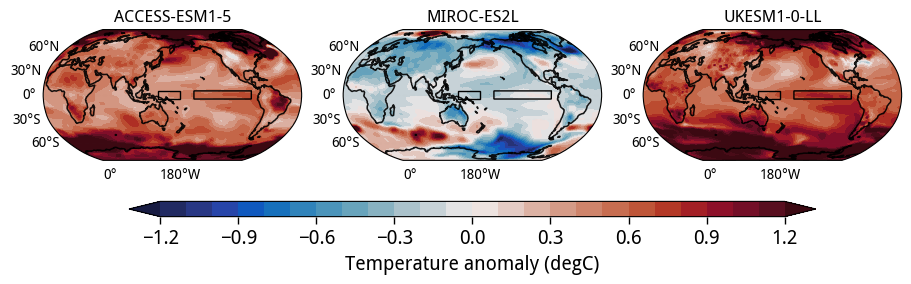

In [84]:
plot_maps(xx, yy, zec_changes, titles=models_zec_warming_levels, labels=['']*8, cmap=cmocean.cm.balance, levels=np.arange(-1.2, 1.3, 0.1), cbar_label = 'Temperature anomaly (degC)', nrows=1, ncols=3, figsize=(9,4.5), land_mask_list = [], add_patch=True, add_patch_extra=False, cbar_orientation='horizontal', hatch_type = 'insig', proj=ccrs.Robinson(central_longitude=160))

In [110]:
# fig, axarr = plt.subplots(nrows=1, ncols=3, figsize=(14,4), constrained_layout=True, sharex=True, sharey=True)
# axlist = axarr.flatten()
# for i in range(len(axlist)):
#     xdata0 = pic_dat[models_zec_warming_levels[i]].time.dt.year
#     sst_grad_pic = pic_dat[models_zec_warming_levels[i]].sel(lat = slice(-5, 5), lon = slice(140, 170)).weighted(weights).mean(('lat', 'lon')).isel(time = slice(1, -1), model=0) - pic_dat[models_zec_warming_levels[i]].sel(lat = slice(-5, 5), lon = slice(190, 270)).weighted(weights).mean(('lat', 'lon')).isel(time = slice(1, -1), model=0)
#     axlist[i].plot((xdata0 - xdata0[0])[1:350], sst_grad_pic.isel(time = slice(1, 350)).rolling(time=30, center=True).mean('time'), color='tab:gray', label='piControl', alpha=0.2)
#     axlist[i].axhspan(sst_grad_pic.rolling(time=30, center=True).mean('time').quantile(0.1, 'time'), sst_grad_pic.rolling(time=30, center=True).mean('time').quantile(0.9, 'time'), color='tab:gray', alpha=0.2, lw=0.0)
#     #
#     xdata0 = trans_dat[models_zec_warming_levels[i]].time.dt.year
#     sst_grad_trans = trans_dat[models_zec_warming_levels[i]].sel(lat = slice(-5, 5), lon = slice(140, 170)).weighted(weights).mean(('lat', 'lon')).isel(time = slice(1, -1), model=0) - trans_dat[models_zec_warming_levels[i]].sel(lat = slice(-5, 5), lon = slice(190, 270)).weighted(weights).mean(('lat', 'lon')).isel(time = slice(1, -1), model=0)
#     axlist[i].plot((xdata0 - xdata0[0])[1:-1], sst_grad_trans.rolling(time=30, center=True).mean('time'), color='k', label='1pctCO2')
#     #
#     xdata = stable750_dat[models_zec_warming_levels[i]].time.dt.year
#     sst_grad_stable = stable750_dat[models_zec_warming_levels[i]].sel(lat = slice(-5, 5), lon = slice(140, 170)).weighted(weights).mean(('lat', 'lon')).isel(time = slice(1, -1), model=0) - stable750_dat[models_zec_warming_levels[i]].sel(lat = slice(-5, 5), lon = slice(190, 270)).weighted(weights).mean(('lat', 'lon')).isel(time = slice(1, -1), model=0)
#     axlist[i].plot((xdata - xdata0[0])[1:-1], sst_grad_stable.rolling(time=30, center=True).mean('time'), color='gold', ls='-', label='brch-750PgC')
#     #
#     xdata = stable1000_dat[models_zec_warming_levels[i]].time.dt.year
#     sst_grad_stable = stable1000_dat[models_zec_warming_levels[i]].sel(lat = slice(-5, 5), lon = slice(140, 170)).weighted(weights).mean(('lat', 'lon')).isel(time = slice(1, -1), model=0) - stable1000_dat[models_zec_warming_levels[i]].sel(lat = slice(-5, 5), lon = slice(190, 270)).weighted(weights).mean(('lat', 'lon')).isel(time = slice(1, -1), model=0)
#     axlist[i].plot((xdata - xdata0[0])[1:-1], sst_grad_stable.rolling(time=30, center=True).mean('time'), color='tab:red', ls='-', label='CDR')
#     #
#     xdata = stable2000_dat[models_zec_warming_levels[i]].time.dt.year
#     sst_grad_stable = stable2000_dat[models_zec_warming_levels[i]].sel(lat = slice(-5, 5), lon = slice(140, 170)).weighted(weights).mean(('lat', 'lon')).isel(time = slice(1, -1), model=0) - stable2000_dat[models_zec_warming_levels[i]].sel(lat = slice(-5, 5), lon = slice(190, 270)).weighted(weights).mean(('lat', 'lon')).isel(time = slice(1, -1), model=0)
#     axlist[i].plot((xdata - xdata0[0])[1:-1], sst_grad_stable.rolling(time=30, center=True).mean('time'), color='maroon', ls='-', label='brch-2000PgC')
#     #
#     axlist[i].set_xticks(np.arange(50, 450, 100))
#     # axlist[i].set_yticklabels([])
#     axlist[i].axhline(sst_grad_pic.rolling(time=30, center=True).mean('time').quantile(0.5, 'time'), color='k', ls='-', lw=0.5)
#     axlist[i].grid(alpha=0.1)
#     # axlist[i].set_title(models_zec_warming_levels[i] + f' (n = {len(trans_dat[models_zec_warming_levels[i]].model)})', fontsize=14)
#     axlist[i].set_title(models_zec_warming_levels[i], fontsize=14)

# axlist[0].set_ylabel('Temperature anomaly (degC)')
# # axlist[4].set_ylabel('Temperature anomaly (degC)')
# axlist[0].legend(frameon=False, loc='lower right', fontsize=10)

# plt.subplots_adjust(wspace=0.0, hspace=0.2)
# plt.minorticks_on()
# # plt.ylim(0.5,3.5)
# # sns.despine()

In [111]:
# fig, axarr = plt.subplots(nrows=1, ncols=3, figsize=(14,4), constrained_layout=True, sharex=True, sharey=True)
# axlist = axarr.flatten()
# for i in range(len(axlist)):
#     xdata0 = pic_dat[models_zec_warming_levels[i]].time.dt.year
#     nino34_pic = funcs.detrend_rolling_window(pic_dat[models_zec_warming_levels[i]].sel(lat = slice(-5, 5), lon = slice(-170+360, -120+360)).weighted(weights).mean(('lat', 'lon')), window_size=15).isel(time = slice(1, -1), model=0)
#     axlist[i].plot((xdata0 - xdata0[0])[1:350], nino34_pic.isel(time = slice(1, 350)).rolling(time=30, center=True).std('time'), color='tab:gray', alpha=0.2, label='piControl')
#     # axlist[i].axhline(nino34_pic.rolling(time=30, center=True).std('time').mean('time'), color='k', lw=2.0)
#     # axlist[i].axhline(nino34_pic.rolling(time=30, center=True).std('time').mean('time'), color='k', lw=2.0)
#     axlist[i].axhspan(nino34_pic.rolling(time=30, center=True).std('time').quantile(0.1, 'time'), nino34_pic.rolling(time=30, center=True).std('time').quantile(0.9, 'time'), color='tab:gray', alpha=0.2, lw=0.0)
#     #
#     xdata0 = trans_dat[models_zec_warming_levels[i]].time.dt.year
#     nino34_trans = funcs.detrend_rolling_window(trans_dat[models_zec_warming_levels[i]].sel(lat = slice(-5, 5), lon = slice(-170+360, -120+360)).weighted(weights).mean(('lat', 'lon')), window_size=15).isel(time = slice(1, -1), model=0)
#     axlist[i].plot((xdata0 - xdata0[0])[1:-1], nino34_trans.rolling(time=30, center=True).std('time'), color='k', label='1pctCO2')
#     axlist[i].axhline(nino34_trans.rolling(time=30, center=True).std('time').mean('time'), color='k', lw=2.0)
#     #
#     xdata = stable750_dat[models_zec_warming_levels[i]].time.dt.year
#     nino34_stable = funcs.detrend_rolling_window(stable750_dat[models_zec_warming_levels[i]].sel(lat = slice(-5, 5), lon = slice(-170+360, -120+360)).weighted(weights).mean(('lat', 'lon')), window_size=15).isel(time = slice(1, -1), model=0)
#     axlist[i].plot((xdata - xdata0[0])[1:-1], nino34_stable.rolling(time=30, center=True).std('time'), color='gold', ls='-', label='brch-750PgC')
#     axlist[i].axhline(nino34_stable.rolling(time=30, center=True).std('time').mean('time'), color='gold', ls='-', lw=2.0)
#     #
#     xdata = stable1000_dat[models_zec_warming_levels[i]].time.dt.year
#     nino34_stable = funcs.detrend_rolling_window(stable1000_dat[models_zec_warming_levels[i]].sel(lat = slice(-5, 5), lon = slice(-170+360, -120+360)).weighted(weights).mean(('lat', 'lon')), window_size=15).isel(time = slice(1, -1), model=0)
#     axlist[i].plot((xdata - xdata0[0])[1:-1], nino34_stable.rolling(time=30, center=True).std('time'), color='tab:red', ls='-', label='CDR')
#     axlist[i].axhline(nino34_stable.rolling(time=30, center=True).std('time').mean('time'), color='tab:red', ls='-', lw=2.0)
#     #
#     xdata = stable2000_dat[models_zec_warming_levels[i]].time.dt.year
#     nino34_stable = funcs.detrend_rolling_window(stable2000_dat[models_zec_warming_levels[i]].sel(lat = slice(-5, 5), lon = slice(-170+360, -120+360)).weighted(weights).mean(('lat', 'lon')), window_size=15).isel(time = slice(1, -1), model=0)
#     axlist[i].plot((xdata - xdata0[0])[1:-1], nino34_stable.rolling(time=30, center=True).std('time'), color='maroon', ls='-', label='brch-2000PgC')
#     axlist[i].axhline(nino34_stable.rolling(time=30, center=True).std('time').mean('time'), color='maroon', ls='-', lw=2.0)
#     #
#     axlist[i].set_xticks(np.arange(50, 450, 100))
#     # axlist[i].set_yticklabels([])
#     # axlist[i].axhline(0.0, color='k', ls='-', lw=0.5)
#     axlist[i].grid(alpha=0.1)
#     # axlist[i].set_title(models_zec_warming_levels[i] + f' (n = {len(trans_dat[models_zec_warming_levels[i]].model)})', fontsize=14)
#     axlist[i].set_title(models_zec_warming_levels[i], fontsize=14)

# axlist[0].set_ylabel('ENSO amplitude (degC)')
# # axlist[4].set_ylabel('Temperature anomaly (degC)')
# axlist[0].legend(frameon=False, loc='upper right', fontsize=10)

# plt.subplots_adjust(wspace=0.0, hspace=0.2)
# plt.minorticks_on()
# # plt.ylim(0.5,3.5)
# # sns.despine()

In [112]:
# fig, axarr = plt.subplots(nrows=1, ncols=3, figsize=(14,4), constrained_layout=True, sharex=True, sharey=True)
# axlist = axarr.flatten()
# for i in range(len(axlist)):
#     xdata0 = pic_dat[models_zec_warming_levels[i]].time.dt.year
#     rolling_mag_pic = funcs.detrend_rolling_window(pic_dat[models_zec_warming_levels[i]].sel(lat = slice(-5, 5), lon = slice(-170+360, -120+360)).weighted(weights).mean(('lat', 'lon')), window_size=15).isel(time = slice(1, -1), model=0).rolling(time = 30, center=True).std('time')
#     pic_change = (rolling_mag_pic/rolling_mag_pic.mean('time') - 1)*100
#     axlist[i].plot((xdata0 - xdata0[0])[1:350], pic_change.isel(time = slice(1, 350)), color='tab:gray', label='piControl', alpha=0.2)
#     axlist[i].axhspan(pic_change.isel(time = slice(1, -1)).quantile(0.1, 'time'), pic_change.isel(time = slice(1, -1)).quantile(0.9, 'time'), color='tab:gray', alpha=0.2, lw=0.0)
#     # bplot = axlist[i].boxplot(pic_change.dropna('time'), boxprops=dict(color='k'), meanline=False, widths=8, patch_artist=True, medianprops=dict(color='k'), showfliers=False, whis=[5, 95], positions=[-20])
#     # for patch, color in zip(bplot['boxes'], ['k']):
#         # patch.set_facecolor(color)

#     # axlist[i].axhspan(nino34_pic.isel(time = slice(1, -1)).rolling(time=30, center=True).std('time').quantile(0.1, 'time'), nino34_pic.isel(time = slice(1, -1)).rolling(time=30, center=True).std('time').quantile(0.9, 'time'), color='tab:gray', alpha=0.3)
#     #
#     xdata0 = trans_dat[models_zec_warming_levels[i]].time.dt.year
#     rolling_mag_trans = funcs.detrend_rolling_window(trans_dat[models_zec_warming_levels[i]].sel(lat = slice(-5, 5), lon = slice(-170+360, -120+360)).weighted(weights).mean(('lat', 'lon')), window_size=15).isel(time = slice(1, -1), model=0).rolling(time = 30, center=True).std('time')
#     trans_change = (rolling_mag_trans/rolling_mag_pic.mean('time') - 1)*100
#     axlist[i].plot((xdata0 - xdata0[0])[1:-1], trans_change, color='k', label='1pctCO2')
#     axlist[i].axhline(trans_change.mean('time'), color='k', lw=2.0)
#     # #
#     xdata = stable750_dat[models_zec_warming_levels[i]].time.dt.year
#     rolling_mag_stable = funcs.detrend_rolling_window(stable750_dat[models_zec_warming_levels[i]].sel(lat = slice(-5, 5), lon = slice(-170+360, -120+360)).weighted(weights).mean(('lat', 'lon')), window_size=15).isel(time = slice(1, -1), model=0).rolling(time = 30, center=True).std('time')
#     stable_change = (rolling_mag_stable/rolling_mag_pic.mean('time') - 1)*100
#     axlist[i].plot((xdata - xdata0[0])[1:-1], stable_change, color='gold', label='brch-750PgC')
#     axlist[i].axhline(stable_change.mean('time'), color='gold', lw=2.0)
#     #
#     xdata = stable1000_dat[models_zec_warming_levels[i]].time.dt.year
#     rolling_mag_stable = funcs.detrend_rolling_window(stable1000_dat[models_zec_warming_levels[i]].sel(lat = slice(-5, 5), lon = slice(-170+360, -120+360)).weighted(weights).mean(('lat', 'lon')), window_size=15).isel(time = slice(1, -1), model=0).rolling(time = 30, center=True).std('time')
#     stable_change = (rolling_mag_stable/rolling_mag_pic.mean('time') - 1)*100
#     axlist[i].plot((xdata - xdata0[0])[1:-1], stable_change, color='tab:red', label='CDR')
#     axlist[i].axhline(stable_change.mean('time'), color='tab:red', lw=2.0)
#     #
#     xdata = stable2000_dat[models_zec_warming_levels[i]].time.dt.year
#     rolling_mag_stable = funcs.detrend_rolling_window(stable2000_dat[models_zec_warming_levels[i]].sel(lat = slice(-5, 5), lon = slice(-170+360, -120+360)).weighted(weights).mean(('lat', 'lon')), window_size=15).isel(time = slice(1, -1), model=0).rolling(time = 30, center=True).std('time')
#     stable_change = (rolling_mag_stable/rolling_mag_pic.mean('time') - 1)*100
#     axlist[i].plot((xdata - xdata0[0])[1:-1], stable_change, color='maroon', label='brch-2000PgC')
#     axlist[i].axhline(stable_change.mean('time'), color='maroon', lw=2.0)
#     #
#     axlist[i].set_xticks(np.arange(50, 450, 100))
#     axlist[i].set_ylim(-42, 85)
#     # axlist[i].set_xticklabels([str(x) for x in np.arange(50, 450, 100)])
#     axlist[i].axhline(0.0, color='k', lw=0.5)
#     # axlist[i].set_yticklabels([])
#     # axlist[i].axhline(0.0, color='k', ls='-', lw=0.5)
#     axlist[i].grid(alpha=0.1)
#     # axlist[i].set_title(models_zec_warming_levels[i] + f' (n = {len(trans_dat[models_zec_warming_levels[i]].model)})', fontsize=14)
#     axlist[i].set_title(models_zec_warming_levels[i], fontsize=14)

# axlist[0].set_ylabel('$\Delta$ ENSO amplitude (%)')
# # axlist[4].set_ylabel('$\Delta$ ENSO variability (%)')
# axlist[0].legend(frameon=False, loc='upper right', fontsize=10)

# plt.subplots_adjust(wspace=0.0, hspace=0.2)
# plt.minorticks_on()
# # plt.ylim(0.5,3.5)
# # sns.despine()